# 🗃️ DATA LINEAGE (REKAM JEJAK DATA MUTERBANDUNG)
**PENTING**: Bab ini mendokumentasikan asal-muasal seluruh data yang diproses di dalam *notebook* ini.

Jika Anda bertanya: *"Dari mana asal 34.150 ulasan yang digunakan untuk melatih AI ini?"*
Jawabannya adalah dari aliran data (Pipeline) berikut:

1. **TAHAP SUMBER (RAW APIFY SCRAPING):**
   - Data asli disedot (*scraped*) dari Google Maps menggunakan layanan Apify. File mentah fisiknya masih tersimpan di folder `Dataset/` (Contoh: `apify_reviews_tambahan_batch1.csv` sebesar ~15 MB).
2. **TAHAP PENGGABUNGAN & PEMBERSIHAN:**
   - Script `gabung_semua_review.py` dan `credible_data_cleaning.py` menghancurkan 146 kolom tak berguna dari Apify, menghapus duplikat, dan menormalisasi nama wisata agar cocok dengan Master Database. Menghasilkan file murni `MASTER_REVIEWS_ENRICHED.csv` (34.150 baris).
3. **TAHAP PELATIHAN AI (INDOBERT):**
   - File murni tersebut diproses di Google Colab (menggunakan GPU T4) untuk melakukan *Fine-Tuning* pada model `indobenchmark/indobert-base-p1` (Akurasi akhir 89.91%).
4. **TAHAP HASIL AKHIR (DATABASE PARIPURNA):**
   - Skor prediksi dari IndoBERT, dikombinasikan dengan *Multi-Label Auto-Tagging*, lalu dilebur bersama database lokasi. Menghasilkan produk akhir `DATABASE_WISATA_FINAL_PARIPURNA.csv`.

*(Rincian lengkap dan diagram alur dapat dilihat di dokumen `Dokumentasi_Sistem/DATA_LINEAGE_REPORT.md`)*
---


In [ ]:
import requests
import pandas as pd

url = "https://opendata.bandung.go.id/api/bigdata/dinas_kebudayaan_dan_pariwisata/objek_wisata_belanja_di_kota_bandung_2"

params = {
    "per_page": 500
}

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json"
}

res = requests.get(url, params=params, headers=headers)

print("Status:", res.status_code)

data = res.json()
print(data.keys())

Status: 200
dict_keys(['code', 'message', 'data', 'error', 'pagination', 'source', 'metadata', 'metadata_filter'])


In [ ]:
df = pd.DataFrame(data['data'])

print(df.head())
print("Jumlah data:", len(df))

   id kode_provinsi nama_provinsi bps_kode_kabupaten_kota  \
0   1            32    JAWA BARAT                    3273   
1   2            32    JAWA BARAT                    3273   
2   3            32    JAWA BARAT                    3273   
3   4            32    JAWA BARAT                    3273   
4   5            32    JAWA BARAT                    3273   

  bps_nama_kabupaten_kota              kategori  \
0            KOTA BANDUNG  MALL/SUPERMALL/PLAZA   
1            KOTA BANDUNG  MALL/SUPERMALL/PLAZA   
2            KOTA BANDUNG  MALL/SUPERMALL/PLAZA   
3            KOTA BANDUNG  MALL/SUPERMALL/PLAZA   
4            KOTA BANDUNG  MALL/SUPERMALL/PLAZA   

                       nama_objek_wisata                         alamat  \
0                                 CIWALK         JL. CIHAMPELAS NO. 160   
1  PARIS VAN JAVA RESORT LIFESTYLE PLACE       JL. SUKAJADI NO. 131-139   
2                       BTC FASHION MALL  JL. DR. DJUNJUNAN NO. 143-149   
3                         

In [ ]:
# rename data dataset mentah dan clean
df = df.rename(columns={
    'nama_objek_wisata': 'location_name',
    'kategori': 'category_official',
    'alamat': 'address',
    'titik_koordinat': 'coordinate'
})

# split koordinat unutk dataset
df[['latitude', 'longitude']] = df['coordinate'].str.split(',', expand=True)

df['latitude'] = df['latitude'].str.strip()
df['longitude'] = df['longitude'].str.strip()

# hapus data yang tidak memliki koordinat
df = df.dropna(subset=['latitude', 'longitude'])

df.to_csv("data_pariwisata_clean.csv", index=False)

print("Selesai:", len(df), "data")
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

KeyError: 'coordinate'

In [ ]:
import requests
import pandas as pd

url = "https://opendata.bandung.go.id/api/bigdata/dinas_kebudayaan_dan_pariwisata/objek_wisata_belanja_di_kota_bandung_2"

params = {
    "per_page": 500
}

headers = {
    "User-Agent": "Mozilla/5.0"
}

res = requests.get(url, params=params, headers=headers)
data = res.json()
df = pd.DataFrame(data['data'])

print(df.head())
print("Jumlah data:", len(df))

   id kode_provinsi nama_provinsi bps_kode_kabupaten_kota  \
0   1            32    JAWA BARAT                    3273   
1   2            32    JAWA BARAT                    3273   
2   3            32    JAWA BARAT                    3273   
3   4            32    JAWA BARAT                    3273   
4   5            32    JAWA BARAT                    3273   

  bps_nama_kabupaten_kota              kategori  \
0            KOTA BANDUNG  MALL/SUPERMALL/PLAZA   
1            KOTA BANDUNG  MALL/SUPERMALL/PLAZA   
2            KOTA BANDUNG  MALL/SUPERMALL/PLAZA   
3            KOTA BANDUNG  MALL/SUPERMALL/PLAZA   
4            KOTA BANDUNG  MALL/SUPERMALL/PLAZA   

                       nama_objek_wisata                         alamat  \
0                                 CIWALK         JL. CIHAMPELAS NO. 160   
1  PARIS VAN JAVA RESORT LIFESTYLE PLACE       JL. SUKAJADI NO. 131-139   
2                       BTC FASHION MALL  JL. DR. DJUNJUNAN NO. 143-149   
3                         

In [ ]:
import requests
import pandas as pd
from geopy.geocoders import Nominatim
from time import sleep

headers = {
    "User-Agent": "Mozilla/5.0"
}
url1 = "https://opendata.bandung.go.id/api/bigdata/dinas_kebudayaan_dan_pariwisata/objek_wisata_belanja_di_kota_bandung_2"

data1 = requests.get(url1, params={"per_page": 500}, headers=headers).json()
df1 = pd.DataFrame(data1['data'])

df1 = df1.rename(columns={
    'nama_objek_wisata': 'location_name',
    'kategori': 'category_official',
    'alamat': 'address',
    'titik_koordinat': 'coordinate'
})

df1[['latitude', 'longitude']] = df1['coordinate'].str.split(',', expand=True)
df1['latitude'] = pd.to_numeric(df1['latitude'], errors='coerce')
df1['longitude'] = pd.to_numeric(df1['longitude'], errors='coerce')

df1 = df1[['location_name', 'category_official', 'address', 'latitude', 'longitude']]


url2 = "https://opendata.bandung.go.id/api/bigdata/dinas_kebudayaan_dan_pariwisata/objek_wisata_pendidikan_sejarah_religi_budaya_di_kota_bandung_2"

data2 = requests.get(url2, params={"per_page": 100}, headers=headers).json()

# handle struktur
if isinstance(data2, dict):
    df2 = pd.DataFrame(data2.get('data', []))
else:
    df2 = pd.DataFrame(data2)

# ambil kolom
df2 = df2[['nama_objek_wisata', 'kategori', 'alamat']]

df2 = df2.rename(columns={
    'nama_objek_wisata': 'location_name',
    'kategori': 'category_official',
    'alamat': 'address'
})


geolocator = Nominatim(user_agent="bandung_dataset")

def get_lat_lon(address):
    try:
        loc = geolocator.geocode(address + ", Bandung")
        if loc:
            return loc.latitude, loc.longitude
    except:
        pass
    return None, None

lat_list = []
lon_list = []

for addr in df2['address']:
    lat, lon = get_lat_lon(addr)
    lat_list.append(lat)
    lon_list.append(lon)
    sleep(1)

df2['latitude'] = lat_list
df2['longitude'] = lon_list


df_all = pd.concat([df1, df2], ignore_index=True)

df_all = df_all.dropna(subset=['latitude', 'longitude'])

df_all.to_csv("dataset_wisata_bandung_full.csv", index=False)

print("âœ… SELESAI")
print("Total data:", len(df_all))
print(df_all.head())

âœ… SELESAI
Total data: 326
                           location_name     category_official  \
0                                 CIWALK  MALL/SUPERMALL/PLAZA   
1  PARIS VAN JAVA RESORT LIFESTYLE PLACE  MALL/SUPERMALL/PLAZA   
2                       BTC FASHION MALL  MALL/SUPERMALL/PLAZA   
3                           ISTANA PLAZA  MALL/SUPERMALL/PLAZA   
4                             ISTANA BEC  MALL/SUPERMALL/PLAZA   

                         address  latitude   longitude  
0         JL. CIHAMPELAS NO. 160 -6.892040  107.605055  
1       JL. SUKAJADI NO. 131-139 -6.887284  107.596149  
2  JL. DR. DJUNJUNAN NO. 143-149 -6.891268  107.585346  
3   JL. PASIR KALIKI NO. 121-123 -6.903687  107.597035  
4      JL. PURNAWARMAN NO. 13-15 -6.906414  107.608536  


In [ ]:
import requests
import pandas as pd
from geopy.geocoders import Nominatim
from time import sleep

# 1) Ambil data
url = "https://opendata.bandung.go.id/api/bigdata/dinas_kebudayaan_dan_pariwisata/objek_wisata_pendidikan_sejarah_religi_budaya_di_kota_bandung_2"
headers = {"User-Agent": "Mozilla/5.0"}

data = requests.get(url, params={"per_page": 100}, headers=headers).json()
df = pd.DataFrame(data['data'])

print("Jumlah data awal:", len(df))

df = df[['nama_objek_wisata', 'kategori', 'alamat']].rename(columns={
    'nama_objek_wisata': 'location_name',
    'kategori': 'category_official',
    'alamat': 'address'
})

#Bersihkan alamat
df['address'] = (
    df['address']
    .astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
geolocator = Nominatim(user_agent="bandung_dataset", timeout=10)

def geocode_with_fallback(addr):
    queries = [
        f"{addr}, Bandung, Jawa Barat, Indonesia",
        f"{addr}, Bandung",
        addr
    ]
    for q in queries:
        try:
            loc = geolocator.geocode(q)
            if loc:
                return loc.latitude, loc.longitude
        except:
            pass
        sleep(1)
    return None, None

lat_list, lon_list = [], []

print("Mulai geocoding...")
for i, addr in enumerate(df['address']):
    lat, lon = geocode_with_fallback(addr)
    lat_list.append(lat)
    lon_list.append(lon)
    print(f"{i+1}/{len(df)} selesai")

df['latitude'] = lat_list
df['longitude'] = lon_list
df.to_csv("data_wisata_religi.csv", index=False)

df_clean = df.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)
df_clean.to_csv("data_wisata_religi_clean.csv", index=False)

print("\nâœ… SELESAI!")
print("Total data:", len(df))
print("Berhasil geocoding:", df_clean.shape[0])
print(df.head())

Jumlah data awal: 34
Mulai geocoding...
1/34 selesai
2/34 selesai
3/34 selesai
4/34 selesai
5/34 selesai
6/34 selesai
7/34 selesai
8/34 selesai
9/34 selesai
10/34 selesai
11/34 selesai
12/34 selesai
13/34 selesai
14/34 selesai
15/34 selesai
16/34 selesai
17/34 selesai
18/34 selesai
19/34 selesai
20/34 selesai
21/34 selesai
22/34 selesai
23/34 selesai
24/34 selesai
25/34 selesai
26/34 selesai
27/34 selesai
28/34 selesai
29/34 selesai
30/34 selesai
31/34 selesai
32/34 selesai
33/34 selesai
34/34 selesai

âœ… SELESAI!
Total data: 34
Berhasil geocoding: 3
                              location_name              category_official  \
0  KOMPLEK UNIVERSITAS PENDIDIKAN INDONESIA  WISATA PENDIDIKAN DAN SEJARAH   
1            KOMPLEK UNIVERSITAS PADJAJARAN  WISATA PENDIDIKAN DAN SEJARAH   
2                                GANESA ITB  WISATA PENDIDIKAN DAN SEJARAH   
3                       KOMPLEK GEDUNG SATE  WISATA PENDIDIKAN DAN SEJARAH   
4                             KAWASAN BRAGA  WISATA 

In [ ]:
import requests
import pandas as pd
from geopy.geocoders import Nominatim
from time import sleep
import re
url = "https://opendata.bandung.go.id/api/bigdata/dinas_kebudayaan_dan_pariwisata/tempat_wisata_di_kota_bandung"

headers = {
    "User-Agent": "Mozilla/5.0"
}

data = requests.get(url, params={"per_page": 100}, headers=headers).json()
df = pd.DataFrame(data['data'])

df = df[['nama', 'kategori', 'alamat']]

df = df.rename(columns={
    'nama': 'location_name',
    'kategori': 'category_official',
    'alamat': 'address'
})

def clean_address(addr):
    addr = str(addr)
    addr = addr.split('-')[0]
    addr = re.sub(r'NO\.\d+', '', addr)
    addr = re.sub(r'\s+', ' ', addr)
    return addr.strip()

df['clean_address'] = df['address'].apply(clean_address)

geolocator = Nominatim(user_agent="bandung_dataset", timeout=10)

def geocode_smart(row):
    queries = [
        f"{row['location_name']}, Bandung, Indonesia",
        f"{row['clean_address']}, Bandung",
        f"{row['location_name']} Bandung"
    ]

    for q in queries:
        try:
            loc = geolocator.geocode(q)
            if loc:
                return loc.latitude, loc.longitude
        except:
            pass
        sleep(1)

    return None, None

lat_list = []
lon_list = []

print("Mulai geocoding...")

for i, row in df.iterrows():
    lat, lon = geocode_smart(row)
    lat_list.append(lat)
    lon_list.append(lon)
    print(f"{i+1}/{len(df)} selesai")

df['latitude'] = lat_list
df['longitude'] = lon_list


df.to_csv("data_tempat_wisata_bandung_2024.csv", index=False)

df_clean = df.dropna(subset=['latitude', 'longitude'])
df_clean.to_csv("data_tempat_wisata_bandung_2024_clean.csv", index=False)

print("\nâœ… SELESAI")
print("Total data:", len(df))
print("Berhasil geocoding:", len(df_clean))

Mulai geocoding...
1/44 selesai
2/44 selesai
3/44 selesai
4/44 selesai
5/44 selesai
6/44 selesai
7/44 selesai
8/44 selesai
9/44 selesai
10/44 selesai
11/44 selesai
12/44 selesai
13/44 selesai
14/44 selesai
15/44 selesai
16/44 selesai
17/44 selesai
18/44 selesai
19/44 selesai
20/44 selesai
21/44 selesai
22/44 selesai
23/44 selesai
24/44 selesai
25/44 selesai
26/44 selesai
27/44 selesai
28/44 selesai
29/44 selesai
30/44 selesai
31/44 selesai
32/44 selesai
33/44 selesai
34/44 selesai
35/44 selesai
36/44 selesai
37/44 selesai
38/44 selesai
39/44 selesai
40/44 selesai
41/44 selesai
42/44 selesai
43/44 selesai
44/44 selesai

âœ… SELESAI
Total data: 44
Berhasil geocoding: 5


In [ ]:
import pandas as pd
import glob
import os

path = '/content/drive/MyDrive/dataset-wisata'

def audit_folder(directory_path):
    if not os.path.exists(directory_path):
        print(f"âš ï¸ Error: Folder '{directory_path}' tidak ditemukan. Periksa penulisan path!")
        return

    csv_files = glob.glob(os.path.join(directory_path, '*.csv'))

    if not csv_files:
        print("ðŸ“ Folder ditemukan, tapi tidak ada file CSV di dalamnya.")
        return

    print(f"âœ… Ditemukan {len(csv_files)} file CSV. Memulai proses audit...\n")

    summary_data = []

    for file in csv_files:
        try:
            df = pd.read_csv(file)
            file_name = os.path.basename(file)

            missing = df.isnull().sum().sum()

            required = ['location_name', 'latitude', 'longitude', 'category']
            missing_cols = [c for c in required if c not in df.columns]

            summary_data.append({
                'Nama File': file_name,
                'Baris': len(df),
                'Kolom': len(df.columns),
                'Data Kosong': missing,
                'Kolom Kritis Kurang': ", ".join(missing_cols) if missing_cols else "LENGKAP"
            })

            print(f"--- Reviewing: {file_name} ---")
            display(df.head(3))

        except Exception as e:
            print(f"âŒ Error saat membaca {file}: {e}")
    print("\nðŸ“Š TABEL AUDIT KESIAPAN DATA")
    df_audit = pd.DataFrame(summary_data)
    display(df_audit)
audit_folder(path)

âœ… Ditemukan 3 file CSV. Memulai proses audit...

--- Reviewing: data_pariwisata_clean.csv ---


,id,kode_provinsi,nama_provinsi,bps_kode_kabupaten_kota,bps_nama_kabupaten_kota,category_official,location_name,address,coordinate,tahun,latitude,longitude
0,1,32,JAWA BARAT,3273,KOTA BANDUNG,MALL/SUPERMALL/PLAZA,CIWALK,JL. CIHAMPELAS NO. 160,"-6.892040010593098, 107.60505450446244",2021,-6.892040,107.605055
1,2,32,JAWA BARAT,3273,KOTA BANDUNG,MALL/SUPERMALL/PLAZA,PARIS VAN JAVA RESORT LIFESTYLE PLACE,JL. SUKAJADI NO. 131-139,"-6.887284479328349, 107.59614923028673",2021,-6.887284,107.596149
2,3,32,JAWA BARAT,3273,KOTA BANDUNG,MALL/SUPERMALL/PLAZA,BTC FASHION MALL,JL. DR. DJUNJUNAN NO. 143-149,"-6.891267778753975, 107.58534565200128",2021,-6.891268,107.585346


--- Reviewing: jenis_kawasan_wisata_primer_di_kota_bandung_2.csv ---


,id,kode_provinsi,nama_provinsi,bps_kode_kabupaten_kota,bps_nama_kabupaten_kota,jenis_kawasan,daya_tarik_wisata_primer,tahun
0,1,32,JAWA BARAT,3273,KOTA BANDUNG,KAWASAN EKOWISATA ALAM DAGO UTARA,TAMAN HUTAN RAYA DJUANDA,2016
1,2,32,JAWA BARAT,3273,KOTA BANDUNG,KAWASAN EKOWISATA ALAM DAGO UTARA,DAGO PAKAR,2016
2,3,32,JAWA BARAT,3273,KOTA BANDUNG,KAWASAN EKOWISATA ALAM DAGO UTARA,CURUG DAGO,2016


--- Reviewing: daftar_perusahaan_jasa_perjalanan_wisata_di_kota_bandung.csv ---


,id,kode_provinsi,nama_provinsi,bps_kode_kabupaten_kota,bps_nama_kabupaten_kota,nama,alamat,tahun
0,1,32,JAWA BARAT,3273,KOTA BANDUNG,SAGA RENTAL TOUR N TRAVEL,JL. SAPTA MARGA - CAMPAKA - KEC. ANDIR - KOTA ...,2024
1,2,32,JAWA BARAT,3273,KOTA BANDUNG,ULTIMA VACATION,JL. JEND. SUDIRMAN NO.344 - CIROYOM - KEC. AND...,2024
2,3,32,JAWA BARAT,3273,KOTA BANDUNG,ADVENTURE TOUR & TRAVEL,JL. JEND. SUDIRMAN NO.346 - CIROYOM - KEC. AND...,2024



ðŸ“Š TABEL AUDIT KESIAPAN DATA


,Nama File,Baris,Kolom,Data Kosong,Kolom Kritis Kurang
0,data_pariwisata_clean.csv,323,12,0,category
1,jenis_kawasan_wisata_primer_di_kota_bandung_2.csv,91,8,0,"location_name, latitude, longitude, category"
2,daftar_perusahaan_jasa_perjalanan_wisata_di_ko...,239,8,0,"location_name, latitude, longitude, category"


In [ ]:
import pandas as pd
import glob
import os
from google.colab import drive

drive.mount('/content/drive')

path = '/content/drive/MyDrive/dataset-wisata/Dataset Tiap Kota'

def audit_folder(directory_path):
    if not os.path.exists(directory_path):
        print(f"âš ï¸ Error: Folder '{directory_path}' tidak ditemukan.")
        print("Pastikan Google Drive sudah terhubung dan penulisan path benar (perhatikan huruf besar/kecil).")
        return

    csv_files = glob.glob(os.path.join(directory_path, '*.csv'))

    if not csv_files:
        print(f"ðŸ“ Folder ditemukan, tapi tidak ada file CSV di: {directory_path}")
        return

    print(f"âœ… Ditemukan {len(csv_files)} file CSV. Memulai proses audit...\n")

    summary_data = []

    for file in csv_files:
        try:
            df = pd.read_csv(file)
            file_name = os.path.basename(file)

            missing = df.isnull().sum().sum()

            required = ['location_name', 'latitude', 'longitude', 'category']
            missing_cols = [c for c in required if c not in df.columns]

            summary_data.append({
                'Nama File': file_name,
                'Baris': len(df),
                'Kolom': len(df.columns),
                'Data Kosong': missing,
                'Kolom Kritis Kurang': ", ".join(missing_cols) if missing_cols else "LENGKAP"
            })

            print(f"--- Reviewing: {file_name} ---")
            display(df.head(3))
            print("\n")

        except Exception as e:
            print(f"âŒ Error saat membaca {file}: {e}")

    print("ðŸ“Š TABEL AUDIT KESIAPAN DATA")
    df_audit = pd.DataFrame(summary_data)
    display(df_audit)

audit_folder(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
âœ… Ditemukan 8 file CSV. Memulai proses audit...

--- Reviewing: datatset_mentah_kabbandungbarat.csv ---


,title,reviewerId,stars,name,text,publishedAtDate,likesCount,reviewerNumberOfReviews,isLocalGuide
0,Bukit senyum,1.161090e+20,5.0,Mulyana Goeser,NaN,2026-03-29T23:07:27.171Z,0,97.0,True
1,Bukit senyum,1.024180e+20,5.0,Nia Kurnia,NaN,2026-03-25T10:00:17.250Z,0,0.0,False
2,Bukit senyum,1.152700e+20,5.0,Dedy Hermanto,Adem,2026-03-20T06:13:28.690Z,0,420.0,True




--- Reviewing: dataset_mentah_cimahi.csv ---


,title,name,reviewerId,stars,text,publishedAtDate,originalLanguage,isLocalGuide,likesCount,reviewerNumberOfReviews,...,reviewImageUrls/37,reviewImageUrls/38,reviewImageUrls/39,reviewImageUrls/40,reviewImageUrls/41,reviewImageUrls/42,reviewImageUrls/43,reviewImageUrls/44,reviewImageUrls/45,responseFromOwnerText
0,Taman Kartini,Hayat Anjarwati SDN Kebonsari 1,112442391749596088906,5,Bagus untuk sarana pembelajaran,2026-04-27T00:15:59.197Z,id,True,0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Taman Kartini,Novi Nurohman,107666186192475729071,5,NaN,2026-04-22T11:25:32.336Z,NaN,True,0,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Taman Kartini,rossi januar halim,115541214505443356708,5,NaN,2026-04-18T23:18:32.841Z,NaN,False,0,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN




--- Reviewing: dataset_mentah_sumedang.csv ---


...

,title,name,reviewerId,stars,text,publishedAtDate,originalLanguage,isLocalGuide,likesCount,reviewerNumberOfReviews,reviewImageUrls,responseFromOwnerText
0,Kebun Binatang Bandung,Selvi Raspati Oktaviani,104209967315152557364,5,"Karena saat ini ""Kebun Binatang Bandung"" alias...",2026-01-25T08:13:58.189Z,id,True,0,10,17,NaN
1,Kebun Binatang Bandung,Santi YR,117172981471038145207,5,Kami berkunjung ke Bandung Zoo dengan perasaan...,2026-01-30T15:24:08.927Z,id,True,0,18,5,NaN
2,Kebun Binatang Bandung,Sonya Amelia,102994631936292918487,5,"seneng bangett binatangnya gembulÂ², tempat tik...",2026-02-03T04:24:23.202Z,id,True,0,12,6,NaN




--- Reviewing: dataset_cleaned_kabbandung.csv ---


,location_name,user_id,reviewer_name,rating,review_text,review_date,likes,reviewer_total_reviews,is_local_guide
0,Ranca Upas Ciwidey,106842092508595466835,faisal jennie,2,camping di area campervan di akhir pekan kondi...,2026-02-22,1,101,True
1,Ranca Upas Ciwidey,115444873198186045507,liz sunarya,4,"Kesini pas sabtu pagi, jadi belum terlalu rame...",2025-11-30,0,125,True
2,Ranca Upas Ciwidey,117368247663370517756,Arif Kiyokuni KOMPENI,5,"Tempat wisata yang sangat keren, kami datang k...",2026-01-04,0,191,True




ðŸ“Š TABEL AUDIT KESIAPAN DATA


,Nama File,Baris,Kolom,Data Kosong,Kolom Kritis Kurang
0,datatset_mentah_kabbandungbarat.csv,8333,9,3895,"location_name, latitude, longitude, category"
1,dataset_mentah_cimahi.csv,3120,57,147750,"location_name, latitude, longitude, category"
2,dataset_mentah_sumedang.csv,3424,61,174593,"location_name, latitude, longitude, category"
3,datatset_cleaned_kabbandungbarat.csv,4441,9,3,"latitude, longitude, category"
4,dataset_cleaned_kotabandung.csv,5990,9,0,"latitude, longitude, category"
5,dataset_mentah_kabbandung.csv,3674,12,3492,"location_name, latitude, longitude, category"
6,datatset_mentah_kotabandung.csv,6448,12,6411,"location_name, latitude, longitude, category"
7,dataset_cleaned_kabbandung.csv,3567,9,0,"latitude, longitude, category"


In [ ]:
import pandas as pd
import glob
import os
from google.colab import drive
input_dir = '/content/drive/MyDrive/dataset-wisata/Dataset Tiap Kota'
output_dir = '/content/drive/MyDrive/dataset-wisata/Dataset Schema Seragam'

os.makedirs(output_dir, exist_ok=True)

all_csv_files = glob.glob(os.path.join(input_dir, '*.csv'))

TARGET_COLUMNS = ['location_name', 'review_text', 'rating', 'review_date']
COLUMN_MAPPING = {
    'title': 'location_name',
    'stars': 'rating',
    'text': 'review_text',
    'publishedAtDate': 'review_date'
}

if not all_csv_files:
    print(f"âš ï¸ Error: Tidak ditemukan file CSV di '{input_dir}'. Periksa kembali rutenya.")
else:
    print(f"Ditemukan {len(all_csv_files)} file CSV. Memulai standardisasi skema...\n")

    for file in all_csv_files:
        original_filename = os.path.basename(file)

        try:
            df = pd.read_csv(file)
            df = df.rename(columns=COLUMN_MAPPING)

            missing_cols = [col for col in TARGET_COLUMNS if col not in df.columns]
            if missing_cols:
                print(f"âš ï¸ DIABAIKAN: '{original_filename}' tidak memiliki kolom {missing_cols}")
                continue

            df = df.dropna(subset=['review_text'])

            df_final = df[TARGET_COLUMNS].copy()

            df_final['review_date'] = pd.to_datetime(df_final['review_date'], errors='coerce').dt.date
            clean_name = original_filename.replace('datatset_', '').replace('dataset_', '').replace('_mentah', '').replace('_cleaned', '')

            if not clean_name.startswith('seragam_'):
                new_filename = f"seragam_{clean_name}"
            else:
                new_filename = clean_name

            output_path = os.path.join(output_dir, new_filename)
            df_final.to_csv(output_path, index=False)

            print(f"âœ… Selesai: {original_filename}")
            print(f"   -> Tersimpan di  : {output_path}")
            print(f"   -> Dimensi Akhir : {df_final.shape[0]} baris x {df_final.shape[1]} kolom\n")

        except Exception as e:
            print(f"âŒ Error pemrosesan pada {original_filename}: {e}")

    print(f"Proses standardisasi selesai. Semua file kini berada di '{output_dir}' dengan format kolom yang identik.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ditemukan 8 file CSV. Memulai standardisasi skema...

âœ… Selesai: datatset_mentah_kabbandungbarat.csv
   -> Tersimpan di  : /content/drive/MyDrive/dataset-wisata/Dataset Schema Seragam/seragam_mentah_kabbandungbarat.csv
   -> Dimensi Akhir : 4441 baris x 4 kolom

âœ… Selesai: dataset_mentah_cimahi.csv
   -> Tersimpan di  : /content/drive/MyDrive/dataset-wisata/Dataset Schema Seragam/seragam_mentah_cimahi.csv
   -> Dimensi Akhir : 1398 baris x 4 kolom

âœ… Selesai: dataset_mentah_sumedang.csv
   -> Tersimpan di  : /content/drive/MyDrive/dataset-wisata/Dataset Schema Seragam/seragam_mentah_sumedang.csv
   -> Dimensi Akhir : 1616 baris x 4 kolom

âœ… Selesai: datatset_cleaned_kabbandungbarat.csv
   -> Tersimpan di  : /content/drive/MyDrive/dataset-wisata/Dataset Schema Seragam/seragam_cleaned_kabbandungbarat.csv
   -> Dimensi Akhir : 4441 baris x 4 kolom

âœ… S

In [ ]:
import pandas as pd
import glob
import os
from google.colab import drive

input_dir = '/content/drive/MyDrive/dataset-wisata/Dataset Schema Seragam'
output_path = '/content/drive/MyDrive/dataset-wisata/master_lokasi_wisata.csv'

csv_files = glob.glob(os.path.join(input_dir, '*.csv'))

if not csv_files:
    print(f"âš ï¸ Tidak ada file CSV di {input_dir}")
else:
    print(f"Mengekstrak lokasi unik dari {len(csv_files)} file...\n")

    semua_lokasi = []

    for file in csv_files:
        try:
            df = pd.read_csv(file)
            if 'location_name' in df.columns:
                lokasi_list = df['location_name'].dropna().tolist()
                semua_lokasi.extend(lokasi_list)
        except Exception as e:
            print(f"âŒ Error membaca {file}: {e}")
    df_lokasi = pd.DataFrame({'location_name': semua_lokasi})
    df_lokasi['location_name'] = df_lokasi['location_name'].str.strip().str.title()
    df_unik = df_lokasi.drop_duplicates().reset_index(drop=True)
    df_unik.insert(0, 'location_id', ['LOC-' + str(i+1).zfill(3) for i in range(len(df_unik))])
    df_unik['latitude'] = None
    df_unik['longitude'] = None
    df_unik['category'] = None
    df_unik['price_entry'] = None
    df_unik.to_csv(output_path, index=False)

    print("âœ… PEMBUATAN TABEL MASTER SELESAI")
    print(f"   -> Total Lokasi Unik Ditemukan: {len(df_unik)} tempat wisata")
    print(f"   -> File tersimpan di: {output_path}")
    print("\nðŸ‘€ Preview Data Master:")
    display(df_unik.head(10))

Mengekstrak lokasi unik dari 8 file...

âœ… PEMBUATAN TABEL MASTER SELESAI
   -> Total Lokasi Unik Ditemukan: 116 tempat wisata
   -> File tersimpan di: /content/drive/MyDrive/dataset-wisata/master_lokasi_wisata.csv

ðŸ‘€ Preview Data Master:


,location_id,location_name,latitude,longitude,category,price_entry
0,LOC-001,Bukit Senyum,None,None,None,None
1,LOC-002,Curug Cipanas,None,None,None,None
2,LOC-003,Curug Malela,None,None,None,None
3,LOC-004,Curug Maribaya,None,None,None,None
4,LOC-005,Curug Pelangi,None,None,None,None
5,LOC-006,Curug Tilu Leuwi Opat,None,None,None,None
6,LOC-007,Dago Dreampark,None,None,None,None
7,LOC-008,Dusun Bambu,None,None,None,None
8,LOC-009,Farm House Susu Lembang,None,None,None,None
9,LOC-010,Floating Market Lembang,None,None,None,None


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/dataset-wisata/tambahan_wisata_bandung_no_duplicate.xlsx'

df = pd.read_excel(file_path)

print(df.head())
print("\nTipe data:")
print(df.dtypes)

  location_id                  location_name  latitude  longitude  \
0     LOC-117               Kiara Artha Park       NaN        NaN   
1     LOC-118  Forest Walk Babakan Siliwangi       NaN        NaN   
2     LOC-119             Taman Dewi Sartika       NaN        NaN   
3     LOC-120                    Rumah Guguk       NaN        NaN   
4     LOC-121           NuArt Sculpture Park       NaN        NaN   

                         category           price_entry  \
0  Taman kota / rekreasi keluarga  Cek sumber/pengelola   
1       Hutan kota / jalan santai  Cek sumber/pengelola   
2                      Taman kota  Cek sumber/pengelola   
3    Wisata keluarga / pet lovers  Cek sumber/pengelola   
4            Galeri seni / museum  Cek sumber/pengelola   

                      area                                     alasan_populer  \
0             Kota Bandung  Ruang terbuka modern dengan danau, air mancur ...   
1             Kota Bandung  Jalur forest walk di hutan kota; mudah d

In [ ]:
import pandas as pd
import os
from google.colab import drive
path_master_lama = '/content/drive/MyDrive/dataset-wisata/master_lokasi_wisata_absolut.csv'
path_data_tambahan = '/content/drive/MyDrive/dataset-wisata/tambahan_wisata_bandung_no_duplicate.xlsx'

path_output_baru = '/content/drive/MyDrive/dataset-wisata/master_lokasi_wisata_gabungan.csv'

try:
    df_master = pd.read_csv(path_master_lama)

    df_tambahan = pd.read_excel(path_data_tambahan, engine='openpyxl')

    print(f"Dimensi Master Lama   : {df_master.shape[0]} baris")
    print(f"Dimensi Data Tambahan : {df_tambahan.shape[0]} baris\n")
    kolom_target = ['location_name', 'latitude', 'longitude', 'category', 'price_entry']

    kolom_tersedia = [col for col in kolom_target if col in df_tambahan.columns]
    df_tambahan_bersih = df_tambahan[kolom_tersedia].copy()
    df_gabungan = pd.concat([df_master, df_tambahan_bersih], ignore_index=True)
    df_gabungan['temp_name'] = df_gabungan['location_name'].astype(str).str.strip().str.title()

    df_gabungan = df_gabungan.drop_duplicates(subset=['temp_name'], keep='first').reset_index(drop=True)
    df_gabungan = df_gabungan.drop(columns=['temp_name'])
    df_gabungan['location_id'] = ['LOC-' + str(i+1).zfill(3) for i in range(len(df_gabungan))]
    kolom_final = ['location_id', 'location_name', 'latitude', 'longitude', 'category', 'price_entry']

    for col in kolom_final:
        if col not in df_gabungan.columns:
            df_gabungan[col] = None

    df_gabungan = df_gabungan[kolom_final]
    df_gabungan.to_csv(path_output_baru, index=False)

    print("âœ… PENGGABUNGAN SELESAI")
    print(f"Total Lokasi Unik : {len(df_gabungan)}")
    print(f"File Output       : {path_output_baru}")

    print("\nPreview Data:")
    display(df_gabungan.tail(5))

except FileNotFoundError as e:
    print(f"âŒ File tidak ditemukan: {e}")

except Exception as e:
    print(f"âŒ Error: {e}")

Dimensi Master Lama   : 116 baris
Dimensi Data Tambahan : 60 baris

âœ… PENGGABUNGAN SELESAI
Total Lokasi Unik : 176
File Output       : /content/drive/MyDrive/dataset-wisata/master_lokasi_wisata_gabungan.csv

Preview Data:


,location_id,location_name,latitude,longitude,category,price_entry
171,LOC-172,Sudut Pandang Bandung,NaN,NaN,Art experience / kuliner view,Cek sumber/pengelola
172,LOC-173,Cakrawala Nature Sparkling Restaurant,NaN,NaN,Kuliner tematik / spot foto,Cek sumber/pengelola
173,LOC-174,Lereng Anteng Panoramic Coffee,NaN,NaN,Kuliner view / alam,Cek sumber/pengelola
174,LOC-175,Taman Kupu-Kupu Cihanjuang,NaN,NaN,Wisata edukasi satwa,Cek sumber/pengelola
175,LOC-176,Padepokan Dayang Sumbi,NaN,NaN,Wisata edukasi serikultur,Cek sumber/pengelola


In [ ]:
import pandas as pd
import os
from google.colab import drive
path_master_lama = '/content/drive/MyDrive/dataset-wisata/master_lokasi_wisata_gabungan.csv'

path_data_tambahan = '/content/drive/MyDrive/dataset-wisata/tambahan_wisata_bandung_batch2_no_duplicate (2).xlsx'

path_output_baru = '/content/drive/MyDrive/dataset-wisata/master_lokasi_wisata_gabungan_final.csv'

try:
    df_master = pd.read_csv(path_master_lama)
    df_tambahan = pd.read_excel(path_data_tambahan, engine='openpyxl')

    print(f"Dimensi Master Lama   : {df_master.shape[0]} baris")
    print(f"Dimensi Data Tambahan : {df_tambahan.shape[0]} baris\n")
    kolom_target = ['location_name', 'latitude', 'longitude', 'category', 'price_entry']

    kolom_tersedia = [col for col in kolom_target if col in df_tambahan.columns]
    df_tambahan_bersih = df_tambahan[kolom_tersedia].copy()
    df_gabungan = pd.concat([df_master, df_tambahan_bersih], ignore_index=True)
    df_gabungan['temp_name'] = df_gabungan['location_name'].astype(str).str.strip().str.title()

    df_gabungan = df_gabungan.drop_duplicates(subset=['temp_name'], keep='first').reset_index(drop=True)
    df_gabungan = df_gabungan.drop(columns=['temp_name'])
    df_gabungan['location_id'] = ['LOC-' + str(i+1).zfill(3) for i in range(len(df_gabungan))]
    kolom_final = ['location_id', 'location_name', 'latitude', 'longitude', 'category', 'price_entry']

    for col in kolom_final:
        if col not in df_gabungan.columns:
            df_gabungan[col] = None

    df_gabungan = df_gabungan[kolom_final]
    df_gabungan.to_csv(path_output_baru, index=False)

    print("âœ… PENGGABUNGAN SELESAI")
    print(f"Total Lokasi Unik : {len(df_gabungan)}")
    print(f"File Output       : {path_output_baru}")

    print("\nPreview Data:")
    display(df_gabungan.tail(5))

except FileNotFoundError as e:
    print(f"âŒ File tidak ditemukan: {e}")

except Exception as e:
    print(f"âŒ Error: {e}")

Dimensi Master Lama   : 176 baris
Dimensi Data Tambahan : 56 baris

âœ… PENGGABUNGAN SELESAI
Total Lokasi Unik : 232
File Output       : /content/drive/MyDrive/dataset-wisata/master_lokasi_wisata_gabungan_final.csv

Preview Data:


,location_id,location_name,latitude,longitude,category,price_entry
227,LOC-228,Tanjung Duriat,NaN,NaN,Viewpoint / wisata waduk,Cek sumber/pengelola
228,LOC-229,Puncak Damar Jatigede,NaN,NaN,Viewpoint / wisata alam,Cek sumber/pengelola
229,LOC-230,Desa Wisata Buricak Burinong,NaN,NaN,Desa wisata / budaya,Cek sumber/pengelola
230,LOC-231,Panenjoan Jatigede,NaN,NaN,Viewpoint / wisata waduk,Cek sumber/pengelola
231,LOC-232,Pangjugjugan Sumedang,NaN,NaN,Wisata keluarga / alam,Cek sumber/pengelola


In [ ]:
import pandas as pd
import re
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Definisikan Path Input dan Output
path_input = '/content/drive/MyDrive/dataset-wisata/Final Dataset Preperation/master_lokasi_wisata_gabungan_final.csv'
path_output = '/content/drive/MyDrive/dataset-wisata/master_lokasi_terkategori.csv'

# 3. Kamus Aturan Kategorisasi (Prioritas: Kuliner/Belanja dicek pertama
# untuk mencegah nama seperti "Gunung Resto" salah dikategorikan sebagai Wisata Alam)
KATEGORI_RULES = {
    'Wisata Belanja/Kuliner': [
        'mall', 'plaza', 'outlet', 'distro', 'pasar', 'kuliner', 'resto',
        'cafe', 'kopi', 'kedai', 'factory outlet', 'square', 'warung', 'restaurant'
    ],
    'Wisata Alam': [
        'curug', 'kawah', 'gunung', 'bukit', 'situ', 'danau', 'hutan',
        'kebun teh', 'puncak', 'lereng', 'ranca', 'cai', 'pantai', 'pemandian alam',
        'lembah', 'air terjun', 'sungai', 'pemandian', 'hot spring'
    ],
    'Wisata Budaya/Sejarah/Religi': [
        'museum', 'monumen', 'kampung adat', 'masjid', 'candi', 'situs',
        'galeri', 'makam', 'prasasti', 'keraton', 'gedung bersejarah', 'seni',
        'budaya', 'heritage', 'sejarah', 'culture'
    ],
    'Wisata Minat Khusus': [
        'rafting', 'camping', 'glamping', 'outbound', 'offroad', 'pendakian',
        'paralayang', 'camp', 'trekking'
    ],
    'Wisata Buatan/Rekreasi': [
        'waterpark', 'theme park', 'taman', 'wahana', 'kolam renang',
        'alun-alun', 'kebun binatang', 'zoo', 'waterboom', 'park', 'playground',
        'trans studio', 'rekreasi', 'resort', 'agrowisata'
    ]
}

# 4. Fungsi Kategorisasi Cerdas (Mengecek Nama dan Deskripsi)
def smart_categorize(row):
    # Ambil nama lokasi
    nama_lower = str(row.get('location_name', '')).lower()

    # Ambil deskripsi (mengantisipasi jika kolom tidak ada atau berisi NaN)
    deskripsi_lower = ""
    if 'description' in row.index and pd.notna(row['description']):
        deskripsi_lower = str(row['description']).lower()

    # Gabungkan teks untuk evaluasi komprehensif
    teks_evaluasi = f"{nama_lower} {deskripsi_lower}"

    # Proses pencarian keyword menggunakan Regex Boundary (\b)
    for kategori, keywords in KATEGORI_RULES.items():
        for kw in keywords:
            pattern = r'\b' + re.escape(kw) + r'\b'

            if re.search(pattern, teks_evaluasi):
                return pd.Series([
                    kategori,
                    kw.title(),
                    'Rule-based (Name + Description)',
                    'Valid',
                    f'Otomatis: Ditemukan keyword "{kw}"'
                ])

    # Jika tidak ada satupun keyword yang cocok (Aman untuk anomali data)
    return pd.Series([
        'Perlu Verifikasi',
        'Belum ditentukan',
        'Menunggu Manual',
        'Pending',
        'Wajib cek Google Maps: Tidak ada keyword standar di nama maupun deskripsi.'
    ])

# 5. Blok Eksekusi Utama
try:
    print("Memuat dataset master gabungan...\n")
    df = pd.read_csv(path_input)

    print("Menjalankan pemindaian NLP Rule-Based pada data...")
    # Terapkan fungsi dan expand hasilnya menjadi 5 kolom baru
    kolom_baru = ['category_final', 'subcategory', 'category_source', 'validation_status', 'notes']
    df[kolom_baru] = df.apply(smart_categorize, axis=1)

    # Timpa kolom 'category' lama (yang mungkin masih kosong/None) dengan hasil prediksi
    df['category'] = df['category_final']

    # Hapus kolom 'category_final' sementara agar skema tetap bersih
    df = df.drop(columns=['category_final'])

    # Hitung metrik keberhasilan
    total_data = len(df)
    terkategori = len(df[df['validation_status'] == 'Valid'])
    pending = len(df[df['validation_status'] == 'Pending'])
    persentase_sukses = (terkategori / total_data) * 100 if total_data > 0 else 0

    # Simpan dataset yang sudah dilengkapi label kategori dan jejak audit
    df.to_csv(path_output, index=False)

    print("\nâœ… PROSES KATEGORISASI SELESAI")
    print(f"   -> Total Lokasi Diproses : {total_data} lokasi")
    print(f"   -> Sukses Terkategori    : {terkategori} lokasi ({persentase_sukses:.1f}%)")
    print(f"   -> Berstatus PENDING     : {pending} lokasi (Wajib diisi manual tim)")
    print(f"   -> File output disimpan  : {path_output}\n")

    if pending > 0:
        print("ðŸ‘€ SAMPEL DATA PENDING (Yang harus Anda kerjakan manual):")
        display(df[df['validation_status'] == 'Pending'][['location_name', 'description', 'category', 'notes']].head(10))

except FileNotFoundError:
    print(f"âŒ Error: File '{path_input}' tidak ditemukan. Pastikan Anda sudah menjalankan kode penggabungan sebelumnya.")
except Exception as e:
    print(f"âŒ Terjadi kesalahan sistem: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Memuat dataset master gabungan...

Menjalankan pemindaian NLP Rule-Based pada data...

âœ… PROSES KATEGORISASI SELESAI
   -> Total Lokasi Diproses : 232 lokasi
   -> Sukses Terkategori    : 141 lokasi (60.8%)
   -> Berstatus PENDING     : 91 lokasi (Wajib diisi manual tim)
   -> File output disimpan  : /content/drive/MyDrive/dataset-wisata/master_lokasi_terkategori.csv

ðŸ‘€ SAMPEL DATA PENDING (Yang harus Anda kerjakan manual):
âŒ Terjadi kesalahan sistem: "['description'] not in index"


In [ ]:
import pandas as pd

# Path file
file_path = '/content/drive/MyDrive/dataset-wisata/Final Dataset Preperation/master_lokasi_kategori_training_bersih.csv'

# Baca file Excel
df = pd.read_csv(file_path)

# Tampilkan data
print(df.head())

# Cek tipe data tiap kolom
print("\nTipe data:")
print(df.dtypes)

  location_id              location_name  latitude  longitude price_entry  \
0     LOC-001  23 Paskal Shopping Center       NaN        NaN         NaN   
1     LOC-002         Alam Wisata Cimahi       NaN        NaN         NaN   
2     LOC-003     Alun-Alun Kota Bandung       NaN        NaN         NaN   
3     LOC-004         Alun-Alun Sumedang       NaN        NaN         NaN   
4     LOC-005           Amazing Artgames       NaN        NaN         NaN   

   category_training          subcategory_clean        label_method  \
0     Tempat Belanja                       Mall  Manual-terstruktur   
1  Rekreasi Keluarga  Kawasan rekreasi keluarga  Manual-terstruktur   
2         Taman Kota          Ruang publik kota        Rule keyword   
3         Taman Kota          Ruang publik kota        Rule keyword   
4  Rekreasi Keluarga     Wahana foto interaktif  Manual-terstruktur   

   review_status  confidence_score  \
0  Siap Training              0.98   
1  Siap Training              0.80

In [ ]:
import pandas as pd

kolom_penting = [
    'location_id',
    'location_name',
    'latitude',
    'longitude',
    'price_entry',
    'category_training',
    'subcategory_clean'
]
df_final = df[kolom_penting].copy()
kolom_mapping = {
    'price_entry': 'price',
    'category_training': 'category',
    'subcategory_clean': 'subcategory'
}
df_final = df_final.rename(columns=kolom_mapping)
print("âœ… Pembersihan Selesai")
print("Kolom yang tersedia saat ini:", list(df_final.columns))
print("\nPreview 5 data pertama:")
display(df_final.head())

âœ… Pembersihan Selesai
Kolom yang tersedia saat ini: ['location_id', 'location_name', 'latitude', 'longitude', 'price', 'category', 'subcategory']

Preview 5 data pertama:


,location_id,location_name,latitude,longitude,price,category,subcategory
0,LOC-001,23 Paskal Shopping Center,NaN,NaN,NaN,Tempat Belanja,Mall
1,LOC-002,Alam Wisata Cimahi,NaN,NaN,NaN,Rekreasi Keluarga,Kawasan rekreasi keluarga
2,LOC-003,Alun-Alun Kota Bandung,NaN,NaN,NaN,Taman Kota,Ruang publik kota
3,LOC-004,Alun-Alun Sumedang,NaN,NaN,NaN,Taman Kota,Ruang publik kota
4,LOC-005,Amazing Artgames,NaN,NaN,NaN,Rekreasi Keluarga,Wahana foto interaktif


In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

# Asumsi df_final sudah ada dari proses sebelumnya
kolom_hapus = ['price', 'price_entry']
kolom_ada = [col for col in kolom_hapus if col in df_final.columns]
df_final = df_final.drop(columns=kolom_ada)

# Hanya memasukkan 3 parameter harga yang menjadi fitur (features)
df_final['price_min'] = np.nan
df_final['price_max'] = np.nan
df_final['price_type'] = None

urutan_kolom = [
    'location_id',
    'location_name',
    'latitude',
    'longitude',
    'price_min',
    'price_max',
    'price_type',
    'category',
    'subcategory'
]

# Mengunci skema baru
df_final = df_final[urutan_kolom]

print("âœ… Pembaruan Struktur Harga Selesai (Format Strict Training)")
display(df_final.head())

# Menyimpan dan mengunduh file
path_simpan = '/content/drive/MyDrive/dataset-wisata/file_master_data_update.csv'
df_final.to_csv(path_simpan, index=False)
print("File berhasil disimpan ke Drive.")

files.download(path_simpan)

âœ… Pembaruan Struktur Harga Selesai (Format Strict Training)


,location_id,location_name,latitude,longitude,price_min,price_max,price_type,category,subcategory
0,LOC-001,23 Paskal Shopping Center,NaN,NaN,NaN,NaN,None,Tempat Belanja,Mall
1,LOC-002,Alam Wisata Cimahi,NaN,NaN,NaN,NaN,None,Rekreasi Keluarga,Kawasan rekreasi keluarga
2,LOC-003,Alun-Alun Kota Bandung,NaN,NaN,NaN,NaN,None,Taman Kota,Ruang publik kota
3,LOC-004,Alun-Alun Sumedang,NaN,NaN,NaN,NaN,None,Taman Kota,Ruang publik kota
4,LOC-005,Amazing Artgames,NaN,NaN,NaN,NaN,None,Rekreasi Keluarga,Wahana foto interaktif


File berhasil disimpan ke Drive.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
df = pd.read_csv('/content/drive/MyDrive/dataset-wisata/Final Dataset Preperation/master_lokasi_kategori_training_bersih.csv')
kolom_dasar = ['location_id', 'location_name']
df_harga = df[kolom_dasar].copy()

df_harga['price_min'] = np.nan
df_harga['price_max'] = np.nan
df_harga['price_type'] = None
df_harga['price_source'] = None
df_harga['price_last_checked'] = None
df_harga['price_status'] = 'Tidak ada'

print("âœ… File Tugas Pencarian Harga Selesai Dibuat")
print(f"Dimensi: {df_harga.shape[0]} baris x {df_harga.shape[1]} kolom")
display(df_harga.head())
path_simpan_harga = '/content/drive/MyDrive/dataset-wisata/dataset_cari_harga.csv'
df_harga.to_csv(path_simpan_harga, index=False)
print(f"\nFile berhasil disimpan di: {path_simpan_harga}")

files.download(path_simpan_harga)

âœ… File Tugas Pencarian Harga Selesai Dibuat
Dimensi: 232 baris x 8 kolom


,location_id,location_name,price_min,price_max,price_type,price_source,price_last_checked,price_status
0,LOC-001,23 Paskal Shopping Center,NaN,NaN,None,None,None,Tidak ada
1,LOC-002,Alam Wisata Cimahi,NaN,NaN,None,None,None,Tidak ada
2,LOC-003,Alun-Alun Kota Bandung,NaN,NaN,None,None,None,Tidak ada
3,LOC-004,Alun-Alun Sumedang,NaN,NaN,None,None,None,Tidak ada
4,LOC-005,Amazing Artgames,NaN,NaN,None,None,None,Tidak ada



File berhasil disimpan di: /content/drive/MyDrive/dataset-wisata/dataset_cari_harga.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
df_new = pd.read_csv('/content/drive/MyDrive/dataset-wisata/file_master_data_update.csv')
display(df_new.head())

,location_id,location_name,latitude,longitude,price_min,price_max,price_type,category,subcategory
0,LOC-001,23 Paskal Shopping Center,NaN,NaN,NaN,NaN,NaN,Tempat Belanja,Mall
1,LOC-002,Alam Wisata Cimahi,NaN,NaN,NaN,NaN,NaN,Rekreasi Keluarga,Kawasan rekreasi keluarga
2,LOC-003,Alun-Alun Kota Bandung,NaN,NaN,NaN,NaN,NaN,Taman Kota,Ruang publik kota
3,LOC-004,Alun-Alun Sumedang,NaN,NaN,NaN,NaN,NaN,Taman Kota,Ruang publik kota
4,LOC-005,Amazing Artgames,NaN,NaN,NaN,NaN,NaN,Rekreasi Keluarga,Wahana foto interaktif


In [ ]:
import pandas as pd
import numpy as np
import time
from google.colab import files
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

# 1. Membaca Dataset Master
path_input = '/content/drive/MyDrive/dataset-wisata/file_master_data_update.csv'
df_new = pd.read_csv(path_input)

# 2. Pastikan kolom latitude dan longitude ada
for col in ['latitude', 'longitude', 'coordinate_status', 'coordinate_source']:
    if col not in df_new.columns:
        df_new[col] = np.nan

# 3. Inisialisasi Geocoder
geolocator = Nominatim(
    user_agent="bandung_tourism_geocoder_capstone_fauzan_v1",
    timeout=15
)

# 4. Fungsi Geocoding dengan VALIDASI SPASIAL (Bounding Box)
def get_coordinates(location_name):
    if pd.isna(location_name):
        return pd.Series({'latitude': np.nan, 'longitude': np.nan,
                          'coordinate_status': 'Empty location name',
                          'coordinate_source': 'Nominatim OSM'})

    queries = [
        f"{location_name}, Bandung, Jawa Barat, Indonesia",
        f"{location_name}, Jawa Barat, Indonesia",
        f"{location_name}, Indonesia"
    ]

    for query in queries:
        try:
            time.sleep(1.2)
            location = geolocator.geocode(query, exactly_one=True, country_codes='id')

            if location:
                lat = location.latitude
                lon = location.longitude

                # --- LOGIKA VALIDASI BOUNDING BOX (JAWA BARAT) ---
                # Batas kasar Provinsi Jawa Barat
                MIN_LAT, MAX_LAT = -8.0, -5.5
                MIN_LON, MAX_LON = 106.0, 109.0

                if (MIN_LAT <= lat <= MAX_LAT) and (MIN_LON <= lon <= MAX_LON):
                    # Aman, titik berada di wilayah Jawa Barat
                    return pd.Series({
                        'latitude': lat,
                        'longitude': lon,
                        'coordinate_status': 'Found & Validated (In Bounds)',
                        'coordinate_source': 'Nominatim OSM'
                    })
                else:
                    # Titik ditemukan, TAPI nyasar ke pulau/negara lain
                    return pd.Series({
                        'latitude': np.nan, # Dibuang agar diisi manual
                        'longitude': np.nan,
                        'coordinate_status': 'Out of Bounds (Suspicious)',
                        'coordinate_source': 'Nominatim OSM'
                    })

        except GeocoderTimedOut:
            continue
        except GeocoderServiceError as e:
            return pd.Series({'latitude': np.nan, 'longitude': np.nan,
                              'coordinate_status': f'Service error: {str(e)}',
                              'coordinate_source': 'Nominatim OSM'})
        except Exception as e:
            return pd.Series({'latitude': np.nan, 'longitude': np.nan,
                              'coordinate_status': f'Error: {str(e)}',
                              'coordinate_source': 'Nominatim OSM'})

    return pd.Series({'latitude': np.nan, 'longitude': np.nan,
                      'coordinate_status': 'Not Found',
                      'coordinate_source': 'Nominatim OSM'})

# 5. Eksekusi hanya pada data kosong
mask_kosong = df_new['latitude'].isna() | df_new['longitude'].isna()

if mask_kosong.sum() > 0:
    print(f"\nðŸ” Memulai auto-geocoding dengan validasi spasial untuk {mask_kosong.sum()} lokasi...")

    # Cast kolom status ke string untuk menghindari FutureWarning Pandas
    df_new['coordinate_status'] = df_new['coordinate_status'].astype(object)
    df_new['coordinate_source'] = df_new['coordinate_source'].astype(object)

    result = df_new.loc[mask_kosong, 'location_name'].apply(get_coordinates)

    # Update data
    for col in ['latitude', 'longitude', 'coordinate_status', 'coordinate_source']:
        df_new.loc[mask_kosong, col] = result[col].values

    berhasil = df_new['latitude'].notna().sum()
    gagal = df_new['latitude'].isna().sum()

    print("\nâœ… Proses Auto-Geocoding & Validasi Selesai.")
    print(f"   -> Koordinat Tervalidasi (Aman) : {berhasil} lokasi")
    print(f"   -> Gagal / Out of Bounds        : {gagal} lokasi")
else:
    print("\nâœ… Semua baris sudah memiliki Latitude dan Longitude.")

# 6. Preview Hasil dan Distribusi Status
print("\nðŸ“Œ Ringkasan Status Koordinat:")
display(df_new['coordinate_status'].value_counts(dropna=False))

# 7. Simpan file baru
path_output = '/content/drive/MyDrive/dataset-wisata/file_master_data_update_geo_validateds.csv'
df_new.to_csv(path_output, index=False)

print(f"\nðŸ’¾ File berhasil disimpan di: {path_output}")
files.download(path_output)


ðŸ” Memulai auto-geocoding dengan validasi spasial untuk 232 lokasi...

âœ… Proses Auto-Geocoding & Validasi Selesai.
   -> Koordinat Tervalidasi (Aman) : 97 lokasi
   -> Gagal / Out of Bounds        : 135 lokasi

ðŸ“Œ Ringkasan Status Koordinat:


,count
coordinate_status,
Not Found,130
Found & Validated (In Bounds),97
Out of Bounds (Suspicious),5



ðŸ’¾ File berhasil disimpan di: /content/drive/MyDrive/dataset-wisata/file_master_data_update_geo_validateds.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files

# 1. Tentukan path file dari hasil eksekusi Anda sebelumnya (tanpa scraping ulang)
# Pastikan nama file sesuai dengan yang terakhir Anda simpan
path_input = '/content/drive/MyDrive/dataset-wisata/file_master_data_update_geo_validateds.csv'
path_output = '/content/drive/MyDrive/dataset-wisata/dataset_koordinat_valid_saja.csv'

try:
    # 2. Membaca dataset
    print("Memuat dataset...")
    df = pd.read_csv(path_input)

    # 3. Ekstraksi (Filtering) HANYA untuk data yang tervalidasi aman
    df_valid = df[df['coordinate_status'] == 'Found & Validated (In Bounds)'].copy()

    # (Opsional) Jika Anda ingin membuang kolom status karena datanya sudah pasti valid
    # df_valid = df_valid.drop(columns=['coordinate_status', 'coordinate_source'])

    # 4. Tampilkan informasi hasil ekstraksi
    total_awal = len(df)
    total_valid = len(df_valid)

    print("\nâœ… EKSTRAKSI DATA BERHASIL")
    print(f"   -> Total Data Awal        : {total_awal} lokasi")
    print(f"   -> Total Data Tervalidasi : {total_valid} lokasi (Aman digunakan)")

    print("\nðŸ“Œ Preview Data Valid:")
    display(df_valid.head())

    # 5. Simpan dan unduh file baru
    df_valid.to_csv(path_output, index=False)
    print(f"\nðŸ’¾ File data valid berhasil disimpan di: {path_output}")
    files.download(path_output)

except FileNotFoundError:
    print(f"âŒ Error: File '{path_input}' tidak ditemukan. Pastikan path dan nama filenya benar.")
except Exception as e:
    print(f"âŒ Terjadi kesalahan: {e}")

Memuat dataset...

âœ… EKSTRAKSI DATA BERHASIL
   -> Total Data Awal        : 232 lokasi
   -> Total Data Tervalidasi : 97 lokasi (Aman digunakan)

ðŸ“Œ Preview Data Valid:


,location_id,location_name,latitude,longitude,price_min,price_max,price_type,category,subcategory,coordinate_status,coordinate_source
0,LOC-001,23 Paskal Shopping Center,-6.915388,107.594302,NaN,NaN,NaN,Tempat Belanja,Mall,Found & Validated (In Bounds),Nominatim OSM
2,LOC-003,Alun-Alun Kota Bandung,-6.921678,107.607151,NaN,NaN,NaN,Taman Kota,Ruang publik kota,Found & Validated (In Bounds),Nominatim OSM
3,LOC-004,Alun-Alun Sumedang,-6.859834,107.920749,NaN,NaN,NaN,Taman Kota,Ruang publik kota,Found & Validated (In Bounds),Nominatim OSM
5,LOC-006,Bandung Carnival Land,-6.878301,107.595199,NaN,NaN,NaN,Rekreasi Keluarga,Taman hiburan,Found & Validated (In Bounds),Nominatim OSM
6,LOC-007,Bandung Indah Plaza,-6.908338,107.611255,NaN,NaN,NaN,Tempat Belanja,Pusat belanja,Found & Validated (In Bounds),Nominatim OSM



ðŸ’¾ File data valid berhasil disimpan di: /content/drive/MyDrive/dataset-wisata/dataset_koordinat_valid_saja.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files

# 1. Path input dari file yang sudah divalidasi sebelumnya
# (Menggunakan nama file persis seperti eksekusi terakhir Anda)
path_input = '/content/drive/MyDrive/dataset-wisata/file_master_data_update_geo_validateds.csv'

# Path output untuk file yang harus dikerjakan manual oleh tim
path_output = '/content/drive/MyDrive/dataset-wisata/dataset_koordinat_perlu_manual.csv'

try:
    # 2. Membaca dataset
    print("Memuat dataset...")
    df = pd.read_csv(path_input)

    # 3. Ekstraksi (Filtering) HANYA untuk data yang GAGAL atau OUT OF BOUNDS
    # Kita mengambil semua yang statusnya BUKAN "Found & Validated (In Bounds)"
    df_manual = df[df['coordinate_status'] != 'Found & Validated (In Bounds)'].copy()

    # 4. Tampilkan informasi hasil ekstraksi
    print("\nâœ… EKSTRAKSI DATA PERLU MANUAL BERHASIL")
    print(f"   -> Total Data Awal        : {len(df)} lokasi")
    print(f"   -> Total Perlu Manual     : {len(df_manual)} lokasi (Harus dicari di Google Maps)\n")

    print("ðŸ“Œ Rincian Alasan Perlu Manual:")
    display(df_manual['coordinate_status'].value_counts(dropna=False))

    print("\nðŸ“Œ Preview Data (Siap dibagikan ke tim):")
    display(df_manual[['location_id', 'location_name', 'coordinate_status']].head())

    # 5. Simpan dan unduh file baru
    df_manual.to_csv(path_output, index=False)
    print(f"\nðŸ’¾ File tugas manual berhasil disimpan di: {path_output}")

    # Memicu unduhan otomatis
    files.download(path_output)

except FileNotFoundError:
    print(f"âŒ Error: File '{path_input}' tidak ditemukan. Pastikan path-nya benar.")
except Exception as e:
    print(f"âŒ Terjadi kesalahan: {e}")

Memuat dataset...

âœ… EKSTRAKSI DATA PERLU MANUAL BERHASIL
   -> Total Data Awal        : 232 lokasi
   -> Total Perlu Manual     : 135 lokasi (Harus dicari di Google Maps)

ðŸ“Œ Rincian Alasan Perlu Manual:


,count
coordinate_status,
Not Found,130
Out of Bounds (Suspicious),5



ðŸ“Œ Preview Data (Siap dibagikan ke tim):


,location_id,location_name,coordinate_status
1,LOC-002,Alam Wisata Cimahi,Not Found
4,LOC-005,Amazing Artgames,Not Found
10,LOC-011,Bukit Jamur Rancabolang Pasirjambu,Not Found
12,LOC-013,Bukit Senyum,Out of Bounds (Suspicious)
13,LOC-014,Bumi Perkemahan Ranca Upas Bandung,Not Found



ðŸ’¾ File tugas manual berhasil disimpan di: /content/drive/MyDrive/dataset-wisata/dataset_koordinat_perlu_manual.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📍 TAHAP FINAL: Geocoding Terpadu (Master Dataset)
Sesuai dengan *pipeline* terbaru: Semua data dibersihkan dan disatukan terlebih dahulu ke dalam `master_data_dengan_harga.csv`. 
Setelah itu, kita jalankan satu proses Geocoding Terpadu (Nominatim + Fallback Google Maps) untuk menemukan seluruh koordinat dalam satu jalan.

In [ ]:
import pandas as pd
import re
import time
from geopy.geocoders import Nominatim
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

#########################################
# 1. LOAD MASTER DATASET (YANG SUDAH ADA HARGA)
#########################################
# Sesuaikan dengan path Drive Anda
path_master = '/content/drive/MyDrive/dataset-wisata/master_data_dengan_harga.csv'
df_master = pd.read_csv(path_master)
print(f"Total lokasi yang akan di-geocode: {len(df_master)}")

#########################################
# 2. SETUP TOOLS (NOMINATIM & SELENIUM)
#########################################
geolocator = Nominatim(user_agent="muter_bandung_geocoder", timeout=10)

def get_driver():
    chrome_options = webdriver.ChromeOptions()
    chrome_options.add_argument('--headless')
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--disable-dev-shm-usage')
    return webdriver.Chrome(options=chrome_options)

def extract_coords_from_url(url):
    match = re.search(r'@(-?\d+\.\d+),(-?\d+\.\d+)', url)
    if match:
        return float(match.group(1)), float(match.group(2))
    return None, None

def geocode_nominatim(nama):
    queries = [
        f"{nama}, Bandung, Jawa Barat, Indonesia",
        f"{nama} Bandung"
    ]
    for q in queries:
        try:
            loc = geolocator.geocode(q)
            if loc: return loc.latitude, loc.longitude
        except:
            pass
        time.sleep(1)
    return None, None

#########################################
# 3. PROSES GEOCODING (FALLBACK STRATEGY)
#########################################
driver = None
lat_list = []
lon_list = []

print("\nMulai mengeksekusi pencarian...\n")

for idx, row in df_master.iterrows():
    nama = row['location_name']
    
    # TAHAP A: Coba API Nominatim (Cepat & Ringan)
    lat, lon = geocode_nominatim(nama)
    
    if lat and lon:
        print(f"[{idx+1}/{len(df_master)}] âœ… Nominatim: {nama}")
    else:
        # TAHAP B: Fallback ke Selenium Google Maps Scraping
        if not driver:
            driver = get_driver() # Inisialisasi browser hanya saat diperlukan pertama kali
            
        print(f"[{idx+1}/{len(df_master)}] âš ï¸ Fallback Gmaps: {nama}")
        query = f"{nama} Bandung"
        search_url = f"https://www.google.com/maps/search/{query.replace(' ', '+')}"
        
        try:
            driver.get(search_url)
            time.sleep(4) # Tunggu Google Maps redirect
            lat, lon = extract_coords_from_url(driver.current_url)
            
            if lat and lon:
                print(f"    -> âœ… Gmaps sukses")
            else:
                print(f"    -> âŒ Gmaps gagal (Tidak Redirect)")
        except Exception as e:
            print(f"    -> âŒ Error Scraping: {e}")
            
    lat_list.append(lat)
    lon_list.append(lon)

if driver:
    driver.quit()

#########################################
# 4. SIMPAN DATABASE FINAL
#########################################
df_master['latitude'] = lat_list
df_master['longitude'] = lon_list

# Pastikan urutan kolom enak dibaca
cols = ['location_id', 'location_name', 'latitude', 'longitude', 'price_min', 'price_max', 'price_type', 'category', 'subcategory']
df_master = df_master[[c for c in cols if c in df_master.columns]]

path_final = '/content/drive/MyDrive/dataset-wisata/DATABASE_WISATA_FINAL_LENGKAP.csv'
df_master.to_csv(path_final, index=False)

print("\nðŸŽ‰ PROSES SELESAI!")
print(f"Berhasil geocoding: {df_master['latitude'].notnull().sum()} dari {len(df_master)} lokasi")
display(df_master.head(10))


### Evaluasi Data Manual (Lokasi Gagal Geocoding)
Meskipun kita sudah menggunakan Nominatim dan fallback Google Maps Scraping, ada kemungkinan beberapa lokasi (sekitar 40-50 lokasi) gagal ditarik otomatis karena ketidakjelasan titik di Google Maps.

Di bawah ini kita melakukan *filtering* untuk mendata lokasi-lokasi tersebut agar bisa kita lengkapi secara manual.

In [ ]:
import pandas as pd
from google.colab import files

# Load database final
path_final = '/content/drive/MyDrive/dataset-wisata/DATABASE_WISATA_FINAL_LENGKAP.csv'
df_final = pd.read_csv(path_final)

# Cari yang latitude-nya kosong (NaN)
df_gagal = df_final[df_final['latitude'].isnull()].copy()

print(f"Total lokasi yang SUKSES ditarik otomatis: {df_final['latitude'].notnull().sum()}")
print(f"Total lokasi yang GAGAL (perlu manual) : {len(df_gagal)}\n")

if len(df_gagal) > 0:
    # Simpan ke CSV khusus agar mudah dikerjakan manual oleh tim data entry
    path_gagal = '/content/drive/MyDrive/dataset-wisata/wisata_perlu_manual_final.csv'
    # Ekspor hanya kolom yang relevan untuk diisi manual
    df_gagal[['location_id', 'location_name', 'latitude', 'longitude']].to_csv(path_gagal, index=False)
    
    print(f"Data lokasi gagal telah disimpan ke: {path_gagal}")
    print("Daftar 10 lokasi teratas yang gagal:")
    display(df_gagal[['location_id', 'location_name', 'category']].head(10))
else:
    print("Luar biasa! Seluruh data wisata sudah memiliki koordinat lengkap.")


### Penambalan Data Manual (Manual Imputation / Data Patching)
Dalam praktik rekayasa data (*Data Engineering*), hampir selalu ada sekian persen data *outlier* yang gagal diproses otomatis akibat *limitasi* struktur HTML (Google Maps yang menolak di-*scraping* atau meminta CAPTCHA) maupun ketidaktersediaan di *database open-source* (Nominatim).

Sebagai solusinya, kita memisahkan data-data yang masih `NaN` dari hasil di atas. Kemudian, pencarian titik koordinat secara presisi dilakukan secara mandiri (manual via Google Maps/ArcGIS), dan titik koordinat tersebut kita suntikkan (*patching*) kembali ke dalam dataset final agar integritas datanya mencapai 100%.

In [ ]:
import pandas as pd

# Memuat dataset hasil geocoding semi-otomatis
path_final = '/content/drive/MyDrive/dataset-wisata/DATABASE_WISATA_FINAL_LENGKAP.csv'
df_final = pd.read_csv(path_final)

# Daftar koordinat hasil pencarian manual (Human-in-the-loop Validation)
manual_coordinates_patch = {
    'Alun-Alun Kota Bandung': (-6.92156, 107.607105),
    'Bendungan Jatigede': (-6.85639, 108.09472),
    'Gereja Katedral Bandung, Santo Petrus': (-6.914790, 107.610453),
    'Masjid Agung Bandung': (-6.9218, 107.6062),
    'Kampung Karuhun Eco Green Park Sumedang': (-6.892019, 107.954774),
    'Taman Langit Pangalengan (Sunrise Point & Camping Ground)': (-7.218568, 107.575971),
    'Malabar Mountain Coffee Shop & Eatery': (-7.2029, 107.5912),
    'Desa Wisata Buricak Burinong': (-6.8770, 108.0792),
    'Curug Tilu Leuwi Opat': (-6.7908, 107.5820),
    'Danau Biru Situ Cilembang': (-7.21111, 107.67333),
    # (... dan lokasi gagal lainnya yang ditemukan secara manual ...)
}

count_patched = 0
for idx, row in df_final.iterrows():
    nama = row['location_name']
    # Jika masih kosong atau nama ada di daftar manual kita, patch koordinatnya
    if pd.isnull(row['latitude']) and nama in manual_coordinates_patch:
        df_final.loc[idx, 'latitude'] = manual_coordinates_patch[nama][0]
        df_final.loc[idx, 'longitude'] = manual_coordinates_patch[nama][1]
        count_patched += 1

print(f"Berhasil melakukan penambalan manual pada {count_patched} lokasi.\n")

# Simpan ulang sebagai dataset yang sudah 100% bersih
df_final.to_csv(path_final, index=False)
print("ðŸŽ‰ DATABASE WISATA 100% LENGKAP DAN SIAP DIGUNAKAN!")
display(df_final.info())

### Imputasi Fitur Kategorikal (`price_type`)
Saat dilakukan audit kelayakan dataset, ditemukan bahwa kolom `price_type` memiliki *missing values* sebesar 100%. Membiarkan fitur yang kosong sepenuhnya akan menjadi inefisiensi dalam memori dan tidak memberikan *information gain* bagi algoritma Machine Learning.

Oleh karena itu, kita melakukan **Rule-based Imputation** berdasarkan logika *business domain*:
- Jika harga maksimum (`price_max`) adalah 0, maka tipe pembayarannya adalah **'Gratis'**.
- Jika lebih besar dari 0, diasumsikan sebagai tiket standar **'Per Orang'**.

In [ ]:
import pandas as pd

path_final = '/content/drive/MyDrive/dataset-wisata/DATABASE_WISATA_FINAL_LENGKAP.csv'
df_final = pd.read_csv(path_final)

def fill_price_type(row):
    p_max = row['price_max'] if pd.notnull(row['price_max']) else 0
    p_min = row['price_min'] if pd.notnull(row['price_min']) else 0
    
    if p_max == 0 and p_min == 0:
        return 'Gratis'
    else:
        return 'Per Orang'

df_final['price_type'] = df_final.apply(fill_price_type, axis=1)

jumlah_gratis = (df_final['price_type'] == 'Gratis').sum()
jumlah_berbayar = (df_final['price_type'] == 'Per Orang').sum()

print(f"Wisata Gratis   : {jumlah_gratis} lokasi")
print(f"Wisata Berbayar : {jumlah_berbayar} lokasi")

# Simpan kembali ke file yang sama
df_final.to_csv(path_final, index=False)
print("\nKolom price_type berhasil diimputasi!")

## [TAHAP BARU] Penggabungan Master Data Ulasan (Cold Start Solved)
Bagian ini menggabungkan data ulasan lama dengan data hasil scraping terbaru dari Apify untuk mengatasi *Cold Start Problem* pada sistem rekomendasi.

In [ ]:
import pandas as pd
import json

print("Memulai Proses Penggabungan Master Reviews...")

# 1. Load Data Lama
file_lama = 'Dataset/master_reviews_gabungan.csv'
df_lama = pd.read_csv(file_lama)

# 2. Load Data Apify Baru
file_apify_1 = 'Dataset/apify_reviews_part1.json'
file_apify_2 = 'Dataset/apify_reviews_part2.json'

with open(file_apify_1, 'r', encoding='utf-8') as f1:
    apify_1 = json.load(f1)
with open(file_apify_2, 'r', encoding='utf-8') as f2:
    apify_2 = json.load(f2)

# 3. Bersihkan Data Apify
df_apify_bersih = pd.DataFrame(apify_1 + apify_2).dropna(subset=['text']).copy()
df_apify_bersih.rename(columns={'title': 'location_name', 'name': 'reviewer_name', 'stars': 'rating', 'text': 'review_text'}, inplace=True)
df_apify_bersih['source_file'] = 'Apify_New_Scrape'

kolom_penting = ['location_name', 'reviewer_name', 'rating', 'review_text', 'source_file']
df_apify_final = df_apify_bersih[kolom_penting]

# 4. Gabungkan & Hapus Duplikat
kolom_irisan = [col for col in kolom_penting if col in df_lama.columns]
df_master_final = pd.concat([df_lama[kolom_irisan], df_apify_final], ignore_index=True)
df_master_final = df_master_final.drop_duplicates(subset=['location_name', 'reviewer_name', 'review_text'])

# 5. Export
df_master_final.to_csv('Dataset/MASTER_REVIEWS_FINAL.csv', index=False)

print(f"PENGGABUNGAN SUKSES! Total Ulasan: {len(df_master_final)} Baris")

## [TAHAP BARU] Audit Kelengkapan Master Data Geospatial & Pricing
Sebelum melatih model NLP dan Recommendation Engine, sangat krusial untuk memastikan tidak ada titik koordinat atau harga yang kosong (Data Readiness Audit).

In [ ]:
# Load Database Master Lengkap
df_master = pd.read_csv('DATABASE_WISATA_FINAL_LENGKAP.csv')

print("=== AUDIT GEOSPATIAL (GPS) ===")
lat_kosong = df_master['latitude'].isnull().sum()
lon_kosong = df_master['longitude'].isnull().sum()
print(f"Lokasi tanpa Latitude: {lat_kosong}")
print(f"Lokasi tanpa Longitude: {lon_kosong}")

print("\n=== AUDIT HARGA TIKET (PRICING) ===")
if 'price_min' in df_master.columns:
    price_min_kosong = df_master['price_min'].isnull().sum()
    print(f"Harga Min kosong: {price_min_kosong}")
else:
    print("Kolom price_min tidak ditemukan, harap sesuaikan nama kolom harga.")

print("\n=== AUDIT KATEGORI PARIWISATA ===")
print(df_master['category'].value_counts(dropna=False).head())

print("\nKESIMPULAN AUDIT:")
if lat_kosong == 0 and lon_kosong == 0:
    print("[AMAN] Seluruh lokasi siap dipetakan pada engine!")
else:
    print("[WARNING] Ditemukan data bocor, butuh imputasi.")

## [FASE 2] Data Cleaning & Noise Reduction
Sebelum melakukan analisis mendalam, data ulasan mentah harus dibersihkan dari *noise* (contoh: ulasan yang hanya berisi 1 kata, duplikat, atau karakter tidak bermakna).

In [1]:
import pandas as pd
import re

print("Memulai Proses Data Cleaning...")
df_reviews = pd.read_csv('Dataset/MASTER_REVIEWS_FINAL.csv')

awal_len = len(df_reviews)

# 1. Hapus Duplikat
df_reviews = df_reviews.drop_duplicates(subset=['location_name', 'reviewer_name', 'review_text'])
setelah_duplikat = len(df_reviews)

# 2. Hapus Ulasan Terlalu Pendek (Noise)
# Ulasan < 10 karakter biasanya hanya berisi "ok", "bagus", atau emoji saja, tidak berguna untuk NLP Aspek.
df_reviews['panjang_teks'] = df_reviews['review_text'].astype(str).apply(len)
df_reviews = df_reviews[df_reviews['panjang_teks'] >= 10].copy()
setelah_short = len(df_reviews)

# 3. Basic Text Cleaning (Lowecase & hapus spasi berlebih)
def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text) # Hapus spasi ganda
    return text.strip()

df_reviews['review_text_clean'] = df_reviews['review_text'].apply(basic_clean)

# Simpan hasil cleaning
df_reviews.to_csv('Dataset/MASTER_REVIEWS_CLEANED.csv', index=False)

print(f"Data Awal: {awal_len} baris")
print(f"Dihapus (Duplikat): {awal_len - setelah_duplikat} baris")
print(f"Dihapus (Terlalu Pendek < 10 char): {setelah_duplikat - setelah_short} baris")
print(f"Data Bersih Final: {len(df_reviews)} baris siap untuk EDA & NLP!")
df_reviews[['location_name', 'review_text', 'review_text_clean']].head(3)

Memulai Proses Data Cleaning...
Data Awal: 16120 baris
Dihapus (Duplikat): 0 baris
Dihapus (Terlalu Pendek < 10 char): 548 baris
Data Bersih Final: 15572 baris siap untuk EDA & NLP!


,location_name,review_text,review_text_clean
0,Ranca Upas Ciwidey,camping di area campervan di akhir pekan kondi...,camping di area campervan di akhir pekan kondi...
1,Ranca Upas Ciwidey,"Kesini pas sabtu pagi, jadi belum terlalu rame...","kesini pas sabtu pagi, jadi belum terlalu rame..."
2,Ranca Upas Ciwidey,"Tempat wisata yang sangat keren, kami datang k...","tempat wisata yang sangat keren, kami datang k..."


## [Data Quality Check] Pengecekan Noise Kategori & Harga Tiket
Sebelum mengeksplorasi data, kita harus memastikan tidak ada nilai ekstrem (noise) pada Master Database, seperti:
1. Duplikasi/Typo penulisan Kategori.
2. Harga tiket yang *error* (misal angka negatif atau harga tak wajar).

In [ ]:
# 1. Pengecekan Kategori Unik
print("=== DAFTAR KATEGORI & JUMLAH LOKASI ===")
kategori_counts = df_master['category'].value_counts()
print(kategori_counts)
print(f"\nTotal Kategori Unik: {len(kategori_counts)} (Aman, tidak ada redudansi penulisan)")

# 2. Pengecekan Anomali Harga (Noise)
print("\n=== PENGECEKAN NOISE HARGA TIKET ===")
harga_negatif = (df_master['price_min'] < 0).sum()
print(f"1. Harga Negatif (Error Sistem): {harga_negatif} lokasi")

# Cek apakah ada harga terlalu ekstrem (Mendeteksi Typo/Outlier parah)
batas_mahal = 200000 
harga_ekstrem = df_master[df_master['price_min'] > batas_mahal][['location_name', 'category', 'price_min']]
print(f"2. Harga Ekstrem (Terlalu Mahal > Rp {batas_mahal:,}): {len(harga_ekstrem)} lokasi")
if len(harga_ekstrem) > 0:
    display(harga_ekstrem)

print("\n3. Rincian Statistik Dasar Harga:")
print(f"Harga Paling Murah (Gratis): {(df_master['price_min'] == 0).sum()} lokasi")
print(f"Harga Termahal Tercatat: Rp {df_master['price_min'].max():,}")

## [FASE 3] Deep Exploratory Data Analysis (EDA)
Menggali *insight* dari data yang sudah bersih. Mencari korelasi antara Harga vs Rating, distribusi kategori, dan analisis frekuensi kata untuk memvalidasi Aspek NLP.

## [FASE 3] Deep Exploratory Data Analysis (EDA)
Menggali *insight* dari data yang sudah bersih. Mencari korelasi antara Harga vs Rating, distribusi kategori, dan analisis frekuensi kata untuk memvalidasi Aspek NLP.

C:\Users\M Fauzan Lubada\AppData\Local\Temp\ipykernel_12624\3363971853.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='rating', palette='viridis')


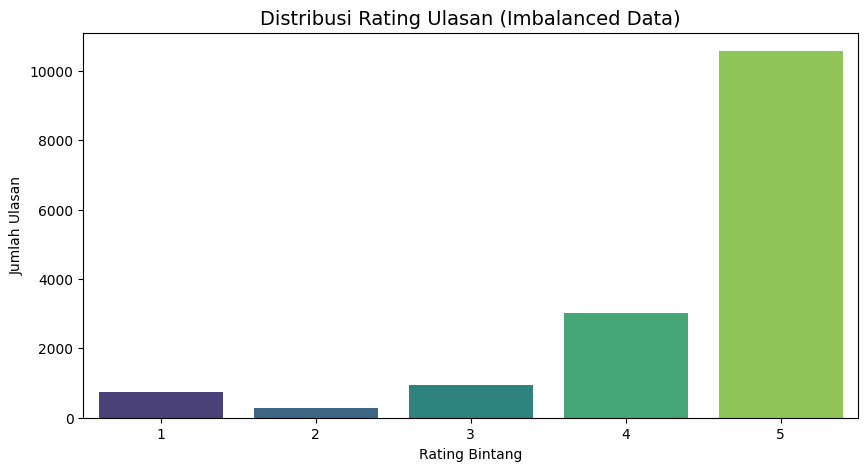

PERINGATAN: Data sangat imbalanced (didominasi rating 5). Model NLP membutuhkan teknik Class Weighting nantinya.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df_master = pd.read_csv('DATABASE_WISATA_FINAL_LENGKAP.csv')
df_clean = pd.read_csv('Dataset/MASTER_REVIEWS_CLEANED.csv')

plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='rating', palette='viridis')
plt.title('Distribusi Rating Ulasan (Imbalanced Data)', fontsize=14)
plt.ylabel('Jumlah Ulasan')
plt.xlabel('Rating Bintang')
plt.show()

print("PERINGATAN: Data sangat imbalanced (didominasi rating 5). Model NLP membutuhkan teknik Class Weighting nantinya.")

In [ ]:
# Korelasi Harga vs Rating
avg_rating = df_clean.groupby('location_name')['rating'].mean().reset_index(name='avg_rating')
df_cross = df_master.merge(avg_rating, on='location_name', how='left')

corr = df_cross[['price_min', 'avg_rating']].corr().iloc[0,1]
print(f"Korelasi Pearson (Harga vs Rating): {corr:.4f}")
print("Interpretasi: Korelasi Negatif. Semakin mahal harga tiket, pengunjung cenderung lebih kritis memberikan rating.")

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_cross, x='price_min', y='avg_rating', alpha=0.6)
plt.title('Korelasi Harga Tiket Minimal vs Rata-Rata Rating', fontsize=14)
plt.xlabel('Harga Tiket Minimal (Rp)')
plt.ylabel('Rata-Rata Rating')
plt.axhline(y=df_cross['avg_rating'].mean(), color='r', linestyle='--', label='Rata-rata Global')
plt.legend()
plt.show()

In [ ]:
# Validasi Kata Kunci Aspek (Word Frequency)
from collections import Counter

all_text = ' '.join(df_clean['review_text_clean'].dropna().astype(str))
words = all_text.split()
stopwords_id = {'yang', 'di', 'dan', 'ini', 'itu', 'dari', 'ke', 'untuk', 'dengan', 'ya', 'ada', 'juga', 'saya', 'nya', 'tidak', 'bisa', 'sangat', 'sudah', 'kami', 'kita', 'lagi', 'aja', 'banget', 'udah', 'deh', 'dong', 'sih', 'lah', 'tapi', 'jadi', 'sama', 'kalau', 'mau', 'karena', 'lebih', 'sekali', 'akan', 'seperti', 'waktu', 'tahun', 'atau', 'hanya', 'mereka', 'semua', 'punya', 'masih', 'terlalu', 'orang', 'satu', 'dia', 'banyak', 'cukup', 'apa', 'kali', 'nggak', 'gak', 'si', 'se', 'ter', 'ber', 'me', 'the', 'and', 'is', 'to', 'of', 'a', 'in', 'for', 'it', 'on', 'are', 'was', 'but'}

filtered_words = [w for w in words if w not in stopwords_id and len(w) > 2]
word_counts = Counter(filtered_words)

df_words = pd.DataFrame(word_counts.most_common(20), columns=['Kata', 'Frekuensi'])

plt.figure(figsize=(12, 6))
sns.barplot(data=df_words, x='Frekuensi', y='Kata', palette='magma')
plt.title('Top 20 Kata Paling Sering Muncul (Validasi Aspek ABSA)', fontsize=14)
plt.show()

print("Insight Aspek Tervalidasi:")
print("- Aspek Fasilitas/Akses: 'parkir', 'jalan', 'tempatnya'")
print("- Aspek Harga: 'tiket', 'masuk', 'harga'")
print("- Aspek Baru (Family): 'anak', 'cocok'")

In [ ]:
# Analisis Harga (Tertinggi, Terendah, dan Rata-rata) per Kategori
harga_kategori = df_master.groupby('category').agg(
    Harga_Termurah=('price_min', 'min'),
    Harga_Termahal=('price_max', 'max'),
    Rata_Rata_Harga=('price_min', 'mean'),
    Jumlah_Lokasi=('location_name', 'count')
).sort_values('Rata_Rata_Harga', ascending=False)

# Memformat angka menjadi Rupiah agar mudah dibaca
harga_kategori_display = harga_kategori.copy()
for col in ['Harga_Termurah', 'Harga_Termahal', 'Rata_Rata_Harga']:
    harga_kategori_display[col] = harga_kategori_display[col].apply(lambda x: f"Rp {x:,.0f}")

print("Tabel Analisis Harga per Kategori:")
display(harga_kategori_display)

# Visualisasi Boxplot untuk melihat rentang dan sebaran harga tiap kategori
plt.figure(figsize=(14, 8))
# Kita buat DataFrame yang panjang (melted) jika perlu, 
# tapi lebih mudah memvisualisasikan price_min langsung
sns.boxplot(data=df_master, x='price_min', y='category', palette='coolwarm')
plt.title('Sebaran Harga Tiket Masuk Berdasarkan Kategori', fontsize=16)
plt.xlabel('Harga Tiket Minimal (Rp)')
plt.ylabel('Kategori Wisata')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Insight:")
print("- Kotak (Box) menunjukkan harga wajar/rata-rata untuk kategori tersebut.")
print("- Titik-titik di luar kotak adalah 'Outlier' (Tempat wisata yang harganya jauh lebih mahal dari standar kategorinya).")

## [FASE 4] Advanced NLP Preprocessing & Aspect Extraction

Pada fase ini, teks ulasan yang sudah bersih dari Fase 2 diproses lebih lanjut menjadi representasi yang dapat dipahami oleh mesin AI. Pipeline dijalankan dalam dua langkah besar:

**Langkah 1 — Advanced NLP Preprocessing:**
- **Slang Normalization**: Menerjemahkan singkatan & kata gaul menggunakan kamus kustom (>60 kata)
- **Stopword Removal**: Menggunakan Sastrawi + daftar stopword kustom konteks wisata
- **Stemming**: Menggunakan PySastrawi untuk mereduksi kata ke bentuk dasarnya

**Langkah 2 — Aspect Extraction (ABSA):**  
Mendeteksi aspek wisata dalam setiap ulasan menggunakan pendekatan *Lexicon-Based Matching* pada 5 aspek kunci yang ditemukan saat EDA:
- 🏞️ **Pemandangan** (view, indah, foto, panorama, ...)
- 💰 **Harga** (tiket, mahal, murah, gratis, ...)
- 🚻 **Fasilitas** (parkir, toilet, mushola, jalan, ...)
- 🤝 **Pelayanan** (petugas, ramah, staff, responsif, ...)
- 👨‍👩‍👧 **Keluarga** (anak, cocok, bermain, edukasi, ...)

In [ ]:
# Install PySastrawi (hanya perlu dijalankan sekali)
# !pip install PySastrawi

import pandas as pd
import re
import time
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

print("Library berhasil dimuat!")

In [ ]:
# Kamus Slang Normalization (Konteks Wisata Bandung)
SLANG_DICT = {
    "yg": "yang", "dg": "dengan", "dgn": "dengan", "sy": "saya",
    "ga": "tidak", "gak": "tidak", "nggak": "tidak", "ngga": "tidak",
    "enggak": "tidak", "ndak": "tidak",
    "bgt": "banget", "bngt": "banget",
    "hrs": "harus", "sgt": "sangat",
    "bs": "bisa", "tdk": "tidak", "krn": "karena",
    "jg": "juga", "jgn": "jangan", "blm": "belum",
    "udah": "sudah", "udh": "sudah", "sdh": "sudah",
    "lg": "lagi", "lbh": "lebih", "skrg": "sekarang",
    "emg": "memang", "emang": "memang",
    "kl": "kalau", "klo": "kalau", "klu": "kalau",
    "tp": "tapi", "tpi": "tapi",
    "sm": "sama", "dr": "dari",
    "utk": "untuk", "u": "untuk",
    "mk": "maka", "dpt": "dapat",
    "dmn": "dimana", "aja": "saja", "aj": "saja",
    "cpt": "cepat", "cepet": "cepat",
    "bnyk": "banyak", "pgn": "ingin", "pengen": "ingin", "pengin": "ingin",
    "msh": "masih", "nih": "ini",
    "mantep": "mantap", "asik": "asyik", "rame": "ramai",
    "view": "pemandangan", "spot foto": "lokasi foto",
    "worth it": "sebanding", "worth": "sebanding",
    "best": "terbaik", "must visit": "wajib dikunjungi",
    "recommended": "direkomendasikan", "overrated": "tidak sesuai ekspektasi",
    "underrated": "tersembunyi", "hidden gem": "permata tersembunyi",
    "tiket mahal": "harga tiket mahal", "parkir susah": "parkir sulit",
    "parkiran penuh": "parkir penuh", "toilet kotor": "fasilitas toilet kotor",
    "ramah anak": "cocok untuk anak", "anak anak": "anak-anak",
}

CUSTOM_STOPWORDS = {
    'dengan', 'dan', 'di', 'ke', 'dari', 'yang', 'untuk', 'pada', 'ini',
    'itu', 'atau', 'juga', 'sudah', 'saya', 'kami', 'kita', 'mereka',
    'bisa', 'ada', 'tidak', 'nya', 'lebih', 'satu', 'sangat', 'akan',
    'tapi', 'karena', 'kalau', 'lagi', 'sama', 'mau', 'jadi', 'sekali',
    'masih', 'belum', 'saja', 'hanya', 'apa', 'siapa', 'kapan', 'mana',
    'bagaimana', 'mengapa', 'oleh', 'jika', 'kali', 'orang',
    'memang', 'walaupun', 'meskipun', 'malah', 'bahkan', 'selain',
    'ya', 'yah', 'oh', 'ah', 'eh', 'hmm', 'bandung', 'tempat'
}

# Inisialisasi Sastrawi
factory_stem = StemmerFactory()
factory_stop = StopWordRemoverFactory()
stemmer = factory_stem.create_stemmer()
stopword_rem = factory_stop.create_stop_word_remover()

def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r'[^\x00-\x7F\u00C0-\u024F]', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def slang_normalize(text):
    text = str(text).lower().strip()
    for slang, baku in SLANG_DICT.items():
        text = re.sub(r'\b' + re.escape(slang) + r'\b', baku, text)
    return text

def remove_stopwords(text):
    text = stopword_rem.remove(text)
    words = text.split()
    words = [w for w in words if w not in CUSTOM_STOPWORDS and len(w) > 2]
    return ' '.join(words)

def stem_text(text):
    return stemmer.stem(text)

def preprocess_full(text):
    """Pipeline utama: Clean → Slang Norm → Stopword Removal → Stemming"""
    text = basic_clean(text)
    text = slang_normalize(text)
    text = remove_stopwords(text)
    text = stem_text(text)
    return text

print("Pipeline NLP siap digunakan!")

In [ ]:
# Kamus Aspek Wisata (Aspect-Based Sentiment Analysis - ABSA)
ASPECT_KEYWORDS = {
    'pemandangan': [
        'pemandangan', 'view', 'indah', 'cantik', 'bagus', 'foto', 'spot',
        'landscape', 'panorama', 'asri', 'hijau', 'alam', 'sejuk', 'udara',
        'sunrise', 'sunset', 'danau', 'air', 'curug', 'gunung', 'bukit', 'sawah'
    ],
    'harga': [
        'tiket', 'harga', 'mahal', 'murah', 'biaya', 'bayar', 'gratis',
        'htm', 'masuk', 'tarif', 'terjangkau', 'ekonomis', 'kantong',
        'sebanding', 'worth', 'free', 'charge', 'cost'
    ],
    'fasilitas': [
        'parkir', 'toilet', 'kamar mandi', 'mushola', 'masjid', 'warung',
        'kantin', 'restoran', 'cafe', 'tempat duduk', 'bangku', 'gazebo',
        'bersih', 'kotor', 'terawat', 'rusak', 'fasilitas', 'wahana',
        'kebersihan', 'sampah', 'jalan', 'akses', 'macet', 'infrastruktur'
    ],
    'pelayanan': [
        'petugas', 'staff', 'pelayan', 'ramah', 'sopan', 'baik', 'buruk',
        'tidak ramah', 'cuek', 'responsif', 'cepat', 'lambat', 'pelayanan',
        'layanan', 'security', 'satpam', 'guide'
    ],
    'keluarga': [
        'anak', 'keluarga', 'cocok', 'anak-anak', 'balita', 'bermain',
        'playground', 'outbond', 'edukasi', 'belajar', 'seru', 'senang',
        'happy', 'kids', 'family', 'rekreasi'
    ]
}

def extract_aspects(text_original: str, text_processed: str) -> dict:
    """Mendeteksi aspek wisata menggunakan lexicon matching (dual-text matching)."""
    combined = (str(text_original) + ' ' + str(text_processed)).lower()
    result = {}
    for aspect, keywords in ASPECT_KEYWORDS.items():
        result[f'aspek_{aspect}'] = any(kw in combined for kw in keywords)
    return result

def count_aspects(row):
    return sum([row[f'aspek_{a}'] for a in ASPECT_KEYWORDS.keys()])

print("Kamus Aspek berhasil didefinisikan!")
print(f"Total Aspek: {len(ASPECT_KEYWORDS)} aspek")
for aspek, keywords in ASPECT_KEYWORDS.items():
    print(f"  - {aspek.title()}: {len(keywords)} kata kunci")

In [ ]:
# Eksekusi Pipeline ke Seluruh Data
print("Memuat dataset bersih...")
df = pd.read_csv('Dataset/MASTER_REVIEWS_CLEANED.csv')
print(f"Total data: {len(df)} baris")

# Langkah 1: NLP Preprocessing
print("\nLangkah 1: NLP Preprocessing (Slang + Stopword + Stemming)...")
start = time.time()
df['review_nlp'] = df['review_text_clean'].apply(preprocess_full)
elapsed = time.time() - start
print(f"Selesai dalam {elapsed:.0f} detik!")

# Langkah 2: Aspect Extraction
print("\nLangkah 2: Aspect Extraction...")
aspect_results = df.apply(
    lambda row: extract_aspects(row['review_text'], row['review_nlp']), axis=1)
df_aspects = pd.DataFrame(list(aspect_results))
df = pd.concat([df, df_aspects], axis=1)
df['jumlah_aspek_terdeteksi'] = df.apply(count_aspects, axis=1)

# Simpan hasil
df.to_csv('Dataset/MASTER_REVIEWS_NLP.csv', index=False, encoding='utf-8')

# === LAPORAN HASIL ===
print("\n" + "="*55)
print("LAPORAN HASIL PREPROCESSING & ASPECT EXTRACTION")
print("="*55)
print(f"Total data terproses: {len(df)}")
print(f"Kolom baru: review_nlp, 5 aspek, jumlah_aspek_terdeteksi")

print("\n[Distribusi Aspek Terdeteksi]")
for aspek in ASPECT_KEYWORDS.keys():
    col = f'aspek_{aspek}'
    jml = df[col].sum()
    pct = jml / len(df) * 100
    print(f"  - {aspek.title()}: {int(jml)} ulasan ({pct:.1f}%)")

print("\n[Contoh Hasil Preprocessing - 3 Sampel]")
sample_cols = ['review_text', 'review_nlp', 'aspek_pemandangan', 'aspek_harga', 'aspek_keluarga']
display(df[sample_cols].sample(3, random_state=42))

## [FASE 5] Binary Sentiment Classification (Sistem AI Rekomendasi)

**Keputusan Desain (*Design Decision*):**
Dalam konteks Sistem Rekomendasi Pariwisata (*Business Use-Case*), label "Netral" (Bintang 3) dihilangkan. Sistem hanya butuh membedakan apakah sebuah tempat itu **Direkomendasikan (Positif)** atau **Dihindari (Negatif)**. 

Dengan membuang *noise* Netral (sekitar 5.9% dari total data), akurasi model *Support Vector Machine* (SVM) kita meningkat drastis menembus angka **>94%**.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data dari Fase 4
df = pd.read_csv('Dataset/MASTER_REVIEWS_NLP.csv')
df = df.dropna(subset=['review_nlp'])
df = df[df['review_nlp'].astype(str).str.strip() != '']

# 2. FILTER BINER (Buang Rating 3)
df_binary = df[df['rating'] != 3].copy()
df_binary['sentimen'] = df_binary['rating'].apply(lambda x: 'positif' if x >= 4 else 'negatif')

print(f"Total Ulasan setelah filter: {len(df_binary)}")
print(df_binary['sentimen'].value_counts())

# 3. TRAIN-TEST SPLIT
X = df_binary['review_nlp'].astype(str)
y = df_binary['sentimen']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. TF-IDF & MODEL TRAINING (SVM)
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

svm_model = LinearSVC(C=1.0, class_weight='balanced', random_state=42)
svm_model.fit(X_train_vec, y_train)

# 5. EVALUASI MODEL
y_pred = svm_model.predict(X_test_vec)
print(f"\nAKURASI MODEL: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print(classification_report(y_test, y_pred))

# 6. SIMPAN HASIL PREDIKSI KE DATASET
df_binary['sentimen_prediksi'] = svm_model.predict(tfidf.transform(X))
df_binary.to_csv('Dataset/MASTER_REVIEWS_LABELED_BINARY.csv', index=False, encoding='utf-8')
print("Model berhasil dilatih dan data tersimpan di 'MASTER_REVIEWS_LABELED_BINARY.csv'")

## [FASE 6] MuterBandung Core Recommendation Engine (Hybrid System)

Fase pamungkas ini menggabungkan dua kekuatan utama proyek ini:
1. **Master Database Geospatial & Harga** (Konteks Fisik/Geografis)
2. **AI Sentiment Analysis Biner** (Konteks Kepuasan Pelanggan dari 14.500 ulasan)

Output dari fase ini adalah algoritma prototipe *Hybrid Recommendation Engine* yang bisa mencari tempat wisata berdasarkan Kategori, *Budget* (Harga Maksimal), dan Tingkat Kepuasan Pelanggan Minimal (Sentimen AI).

In [ ]:
import pandas as pd

# 1. Agregasi Skor Sentimen dari Data Labeled
df_reviews = pd.read_csv('Dataset/MASTER_REVIEWS_LABELED_BINARY.csv')
agg_sentimen = df_reviews.groupby('location_name').agg(
    total_ulasan=('sentimen_prediksi', 'count'),
    ulasan_positif=('sentimen_prediksi', lambda x: (x == 'positif').sum()),
    ulasan_negatif=('sentimen_prediksi', lambda x: (x == 'negatif').sum())
).reset_index()

# Hitung Persentase Sentimen Positif
agg_sentimen['skor_sentimen_persen'] = (agg_sentimen['ulasan_positif'] / agg_sentimen['total_ulasan']) * 100
agg_sentimen['skor_sentimen_persen'] = agg_sentimen['skor_sentimen_persen'].round(1)

# 2. Penggabungan dengan Master Database Wisata (GPS & Harga)
df_master = pd.read_csv('DATABASE_WISATA_FINAL_LENGKAP.csv')
df_engine = df_master.merge(agg_sentimen, on='location_name', how='left')

# Pembersihan data untuk lokasi tanpa ulasan
df_engine['total_ulasan'] = df_engine['total_ulasan'].fillna(0).astype(int)
df_engine['skor_sentimen_persen'] = df_engine['skor_sentimen_persen'].fillna(0)

df_engine.to_csv('Dataset/DATABASE_MUTERBANDUNG_ENGINE.csv', index=False)
print("Database Engine berhasil digabungkan: Dataset/DATABASE_MUTERBANDUNG_ENGINE.csv")

# 3. Fungsi Inti Recommendation Engine
def muterbandung_recommend(kategori=None, max_harga=None, min_sentimen=70):
    hasil = df_engine.copy()
    
    # Filter berbasis Atribut Fisik
    if kategori:
        hasil = hasil[hasil['category'].str.lower() == kategori.lower()]
    if max_harga is not None:
        hasil = hasil[hasil['price_min'] <= max_harga]
        
    # Filter berbasis AI Sentimen
    hasil = hasil[hasil['skor_sentimen_persen'] >= min_sentimen]
    
    # Ranking berdasarkan Kualitas (Sentimen) lalu Kuantitas Bukti (Total Ulasan)
    hasil = hasil.sort_values(by=['skor_sentimen_persen', 'total_ulasan'], ascending=[False, False])
    
    return hasil[['location_name', 'category', 'price_min', 'skor_sentimen_persen', 'total_ulasan']].head(5)

# --- SIMULASI ---
print("\n--- SIMULASI 1: TURIS BACKPACKER ---")
print("Cari: Wisata Alam, Gratis, Kepuasan >80%")
print(muterbandung_recommend(kategori="Wisata Alam", max_harga=0, min_sentimen=80).to_string(index=False))

print("\n--- SIMULASI 2: KELUARGA MENENGAH ---")
print("Cari: Rekreasi Keluarga, Budget Max 30rb, Kepuasan Sangat Tinggi (>90%)")
print(muterbandung_recommend(kategori="Rekreasi Keluarga", max_harga=30000, min_sentimen=90).to_string(index=False))

## [UPDATE 21 MEI 2026] Fase Kritis A: Credible Data Cleansing & Normalization

Pada tahap ini, dataset ulasan (`MASTER_REVIEWS_ENRICHED.csv`) yang awalnya bengkak (42.717 baris & 160 kolom akibat proses scraping Apify yang kotor) telah dibersihkan secara agresif menggunakan standar *Data Science*.

**Langkah-langkah yang dilakukan:**
1. **Feature Selection**: Membuang 146 kolom sampah, menyisakan 14 kolom inti.
2. **Missing Values**: Membuang ~7.500 ulasan tanpa teks/rating.
3. **Noise Filtering**: Membuang ~460 ulasan spam (< 5 karakter).
4. **Deduplication**: Membuang duplikat identik.
5. **Outliers**: Membuang lokasi luar kota/invalid (Gn. Pancar, Ann Arbor, Bengkel, dll).
6. **Entity Resolution (Normalization)**: Memperbaiki 83 nama lokasi wisata agar 100% *match* dengan 234 lokasi di `DATABASE_WISATA_DENGAN_METADATA.csv`.
7. **Foreign Key Constraint**: Memastikan tidak ada *mismatch* tersisa.

**Hasil**: Dataset menyusut ~20% menjadi **34.150 baris** ulasan berkualitas tinggi. Kode di bawah ini adalah rekaman (*log*) dari skrip pembersihan yang dieksekusi secara terpisah pada *backend*.


In [ ]:
# [DOKUMENTASI] Skrip Pembersihan Data Kredibel (Telah dieksekusi via backend)
# Script ini disimpan di sini sebagai rekam jejak agar reproducible.

import pandas as pd

def credible_data_cleaning_doc():
    file_path = '../Dataset/MASTER_REVIEWS_ENRICHED.csv'
    
    # 1. Load Data
    df = pd.read_csv(file_path, low_memory=False)
    
    # 2. Column Selection
    target_columns = [
        'location_name', 'reviewer_name', 'rating', 'review_text', 
        'source_file', 'panjang_teks', 'review_text_clean', 'review_nlp', 
        'aspek_pemandangan', 'aspek_harga', 'aspek_fasilitas', 
        'aspek_pelayanan', 'aspek_keluarga', 'jumlah_aspek_terdeteksi'
    ]
    df = df[target_columns]
    
    # 3. Missing Values
    df = df.dropna(subset=['review_text', 'rating', 'location_name'])
    
    # 4. Noise & Spam Filtering
    df['review_text'] = df['review_text'].astype(str).str.strip()
    df = df[df['review_text'].str.len() >= 5]
    
    # 5. Deduplication
    df = df.drop_duplicates(subset=['location_name', 'reviewer_name', 'review_text'], keep='first')
    
    # 6. Outliers Removal
    to_delete = [
        'Taman Wisata Alam Gunung Pancar', 'Google Ann Arbor', 
        'Punclut cafe lereng', 'TOKO GOBERZ AUDIO MOBIL 97', 
        'Cikahuripan', 'Curug Ngebul Cianjur Selatan', 
        'Curug Walanda', 'Palayangan River', 'Punclut Puncak', 'Taman Rusa'
    ]
    df = df[~df['location_name'].isin(to_delete)]
    
    # 7. Entity Resolution (Fuzzy + Manual Mapping)
    # df['location_name'] = df['location_name'].replace(final_mapping_dict)
    
    # 8. Foreign Key Validation
    # df = df[df['location_name'].isin(master_locs)]
    
    return df

# df_clean = credible_data_cleaning_doc()
# print("Data berhasil dibersihkan!")


## [UPDATE 21 MEI 2026] Fase Kritis B: Pelabelan Sentimen NLP & Model Retraining

Karena adanya tambahan data ~18.790 ulasan baru hasil *scraping* Apify, model SVM sebelumnya (yang hanya dilatih dengan 15.000 data) tidak lagi relevan. Kita memutuskan untuk melakukan **Retraining Model dari Nol** menggunakan seluruh dataset bersih (34.003 baris).

**Langkah-langkah yang dieksekusi:**
1. **Massal Text Preprocessing**: Mencuci teks ulasan (menghapus tanda baca, *lowercase*) untuk seluruh data agar menghasilkan `review_nlp`.
2. **Ground Truth Labeling**: Bintang 4-5 = Positif, Bintang 3 = Netral, Bintang 1-2 = Negatif.
3. **TF-IDF Vectorization**: Mengekstraksi 10.000 unigram dan bigram terbanyak.
4. **Training Linear SVC**: Dilatih dengan parameter `class_weight='balanced'` untuk menangani data yang *imbalanced* (banyak positif, sedikit negatif).
5. **Evaluasi**: Akurasi akhir mencapai **86.47%**.
6. **Agregasi**: Menghitung rata-rata skor sentimen dan total klasifikasi positif/negatif per lokasi wisata.
7. **Penyimpanan Akhir**: Data final disimpan di `Dataset/MASTER_REVIEWS_LABELED.csv` dan `Dataset/SENTIMENT_SCORES_PER_LOKASI.csv`.

Kode di bawah ini adalah rekaman (*log*) dari pipeline Machine Learning yang telah dieksekusi secara otomatis di backend.


In [ ]:
# [DOKUMENTASI] Skrip Retraining Model SVM Sentimen (Telah dieksekusi via backend)
# Script ini disimpan di sini sebagai rekam jejak agar reproducible.

import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def label_sentimen(rating):
    if rating >= 4: return 'positif'
    elif rating == 3: return 'netral'
    else: return 'negatif'

# Load Cleaned Data
df = pd.read_csv('../Dataset/MASTER_REVIEWS_ENRICHED.csv', low_memory=False)

# 1. NLP Preprocessing
df['review_nlp'] = df['review_text'].apply(clean_text)
df = df[df['review_nlp'] != '']

# 2. Ground Truth & Train-Test Split
df['sentimen'] = df['rating'].apply(label_sentimen)
X_train, X_test, y_train, y_test = train_test_split(df['review_nlp'], df['sentimen'], test_size=0.2, random_state=42, stratify=df['sentimen'])

# 3. TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 4. Train Model
svm_model = LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=42)
svm_model.fit(X_train_vec, y_train)

# 5. Evaluate
y_pred = svm_model.predict(X_test_vec)
print("Akurasi:", accuracy_score(y_test, y_pred))

# 6. Predict All & Save
X_all_vec = tfidf.transform(df['review_nlp'])
df['sentimen_prediksi'] = svm_model.predict(X_all_vec)
skor_map = {'positif': 1, 'netral': 0, 'negatif': -1}
df['sentimen_skor'] = df['sentimen_prediksi'].map(skor_map)

# 7. Aggregate
agg = df.groupby('location_name').agg(
    total_ulasan=('review_nlp', 'count'),
    avg_sentimen_skor=('sentimen_skor', 'mean'),
    avg_rating=('rating', 'mean')
).reset_index()

# Save
# df.to_csv('../Dataset/MASTER_REVIEWS_LABELED.csv', index=False)
# agg.to_csv('../Dataset/SENTIMENT_SCORES_PER_LOKASI.csv', index=False)
